# Tuần 05 — Khái quát dữ liệu (1/7): Nền tảng và tính toán xác suất

**UET.MAT1052 — Xác suất thống kê**
ThS. Hoàng Hữu Bách — BM. Khoa học & Kỹ thuật tính toán - Khoa Công nghệ Thông tin, VNU-UET

### Câu hỏi của buổi

Làm sao gán một con số cho sự không chắc chắn? Con số đó thay đổi thế nào khi ta biết thêm thông tin?

### Sau buổi này, bạn làm được

- liệt kê không gian mẫu và viết biến cố bằng ký hiệu tập hợp;
- dùng ba tiên đề và các hệ quả: quy tắc phần bù, quy tắc cộng;
- tính xác suất có điều kiện bằng cách chọn đúng mẫu số;
- dùng quy tắc nhân; phân biệt độc lập với xung khắc;
- dùng công thức xác suất toàn phần, định lý Bayes và sơ đồ cây;
- chỉ ra hai lỗi lập luận trong vụ Sally Clark.

### Cần nhớ từ các buổi trước

- **Tỉ lệ** (Tuần 02). Có 69 trong 86 hộ dùng truyền hình thì tỉ lệ là $69/86\approx0{,}80$.
- **Bảng liên hợp** (Tuần 02). Bảng đếm theo hai biến phân loại, ví dụ "có Internet hay không" × "có truyền hình hay không".
- **Lọc dữ liệu** (Tuần 03). `df.loc[df["different"]]` chỉ giữ các hàng thỏa điều kiện. Tuần này, xác suất có điều kiện chính là "lọc rồi mới đếm".

### Cách học notebook này

1. **Đọc** tình huống.
2. **Đoán** kết quả trước khi chạy ô code.
3. **Chạy** ô bằng `Shift + Enter`.
4. **So sánh** kết quả với dự đoán và tìm lý do nếu lệch.

Khối **Vì sao?** chứa chứng minh; mở ra khi bạn muốn biết công thức từ đâu ra. Đáp án bài tập nằm trong khối thu gọn; hãy tự làm trước khi mở.

### Bản đồ bài học

- Mở đầu: xác suất trả lời câu hỏi gì?
- 1. Hai trò chơi của De Méré
- 2. Không gian mẫu và biến cố
- 3. Từ tập kết quả đến xác suất
- 4. Xác suất có điều kiện, quy tắc nhân và độc lập
- 5. Lời giải bài toán De Méré
- 6. Xác suất toàn phần và định lý Bayes
- 7. Bài tập tổng hợp
- 8. Tóm tắt và lỗi hay gặp
- 9. Tự kiểm tra trước Tuần 06
- 10. Đọc thêm

**Thực hành Plot:** [hướng dẫn Plotnine](./HUONG_DAN_PLOT.md). Các đoạn “Đọc code vẽ” trong bài giải thích những API được dùng ở từng hình. Ô mô phỏng có thể sinh mẫu mới khi chạy lại; để so sánh hai cách vẽ trên cùng mẫu, khởi động lại kernel và chạy toàn bộ notebook với cùng seed sau mỗi lần sửa.

## Ký hiệu dùng trong buổi này

Ví dụ trong bảng: gieo một xúc xắc, $A=\{2,4,6\}$ (ra số chẵn), $B=\{4,5,6\}$ (ra số không nhỏ hơn 4).

| Ký hiệu | Đọc là | Nghĩa | Ví dụ |
|---|---|---|---|
| $\Omega$ | ô-mê-ga | không gian mẫu: mọi kết quả có thể | $\{1,2,3,4,5,6\}$ |
| $\omega\in A$ | ô-mê-ga thuộc A | kết quả $\omega$ làm $A$ xảy ra | $4\in A$ |
| $C\subseteq A$ | C là tập con của A | $C$ xảy ra thì $A$ chắc chắn xảy ra | $\{6\}\subseteq A$ |
| $A\cup B$ | A hợp B | $A$ **hoặc** $B$ xảy ra (ít nhất một) | $\{2,4,5,6\}$ |
| $A\cap B$ | A giao B | $A$ **và** $B$ cùng xảy ra | $\{4,6\}$ |
| $\overline{A}$ | phần bù của A, "không A" | $A$ **không** xảy ra | $\{1,3,5\}$ |
| $A\setminus B$ | A trừ B | $A$ xảy ra nhưng $B$ không | $\{2\}$ |
| $\varnothing$ | tập rỗng | biến cố không thể xảy ra | $A\cap\overline{A}=\varnothing$ |
| $\lvert A\rvert$ | số phần tử của A | số kết quả trong $A$ | $\lvert A\rvert=3$ |
| $P(A)$ | xác suất của A | một số trong đoạn $[0,1]$ | $P(A)=3/6$ |
| $P(A\mid B)$ | xác suất của A khi biết B | xác suất của $A$ khi chỉ xét các kết quả thuộc $B$ | $P(A\mid B)=2/3$ |

**Cách viết khác của phần bù.** Notebook này viết $\overline{A}$. Nhiều tài liệu viết $A^c$; bản dịch STAT 20 viết $A^C$. Ba cách viết có cùng một nghĩa.

**Số hay tập?** $P(A)$ là một **số**, còn $A$ là một **tập** kết quả. Vì vậy $P(A)+P(B)$ có nghĩa (cộng hai số) và $A\cup B$ có nghĩa (hợp hai tập). Còn $A+B$ hay $P(A)\cup P(B)$ thì không có nghĩa.

### Thiết lập tính toán

Ô code dưới nạp thư viện và tạo bộ sinh số ngẫu nhiên.

- `np`, `pd`: NumPy và pandas, để tính toán và lập bảng.
- `stats`: các phân phối xác suất của SciPy.
- `product`: liệt kê mọi bộ kết quả, ví dụ 36 cặp của hai xúc xắc.
- `display`: hiển thị bảng ngay dưới ô code.
- `p9`: Plotnine, để vẽ hình. Mỗi hình được xây từ bảng dữ liệu, `p9.aes(...)` và các lớp `geom_*`, rồi `display(...)` hiển thị ngay dưới ô code.
- `rng = np.random.default_rng(4200)`: bộ sinh số ngẫu nhiên với seed 4200. Cùng seed thì chạy lại cho cùng kết quả mô phỏng.
- `n_games = 50_000`: số ván mô phỏng của mỗi trò chơi ở mục 1.

In [1]:
import numpy as np
import pandas as pd
import plotnine as p9
from scipy import stats
from itertools import product
from IPython.display import display

p9.theme_set(p9.theme_minimal(base_size=11))
rng = np.random.default_rng(4200)
n_games = 50_000


## Mở đầu: xác suất trả lời câu hỏi gì?

Ở Tuần 04, đường hồi quy tóm tắt những quan sát đã có. Chọn một nhóm sinh viên khác thì các con số tóm tắt sẽ khác. Muốn đi từ dữ liệu đang có tới một phát biểu rộng hơn, ta cần mô tả phần dao động do ngẫu nhiên. Xác suất là ngôn ngữ cho việc đó.

![Hình 5.S1. Từ mô tả tới khái quát dữ liệu](figures/01_stat20_generalization_map.jpg)

*Hình 5.S1.* Bốn loại khẳng định của Tuần 01. Nhánh khái quát hóa (generalization) hỏi về một tập đơn vị rộng hơn dữ liệu đang có. Xác suất mô tả bước lấy mẫu và mức dao động; nó không tự sửa được sai lệch do chọn mẫu.
*Nguồn ảnh: bản dịch STAT 20 (`STAT20_in_Vietnamese.html`), Chương 3: Khái quát hóa dữ liệu: Lý thuyết xác suất.*

Vài câu hỏi xác suất quen thuộc, và thứ cần có để trả lời:

| Câu hỏi | Cần gì để trả lời? |
|---|---|
| Khả năng bạn đạt điểm A môn này? | Dữ liệu các lớp trước, ví dụ 32% đạt A. Đó là con số minh họa, không phải dự báo cho lớp của bạn. |
| Khả năng đội tuyển Việt Nam thắng Thái Lan ở trận tới? | Thông tin về hai đội và một mô hình dự báo. |
| Khả năng gieo được hai mặt giống nhau để ra tù trong Cờ tỷ phú? | Chỉ cần đếm. Hai xúc xắc cân đối, độc lập có 6 trong 36 cặp giống nhau, nên là $6/36=1/6$. |
| Khả năng ngày mai trời mưa? | Dữ liệu và mô hình thời tiết. Không suy ra được từ phép đếm. |

Một ví dụ gần với thống kê hơn: nhà máy kiểm tra ngẫu nhiên vài linh kiện từ một lô lớn. Dù chất lượng lô không đổi, tỉ lệ lỗi trong các mẫu vẫn khác nhau. Mô hình xác suất giúp hỏi: mức dao động nào có thể chỉ do cách lấy mẫu? Các buổi sau sẽ xây dựng phương pháp suy luận từ câu hỏi này.

Mọi kết luận số trong bài đều đúng **trong mô hình đã nêu**. Mô phỏng giúp kiểm tra phép tính trong mô hình; nó không chứng minh mô hình đúng với đời thực.

## 1. Hai trò chơi của De Méré

![Hình 5.S2. Bối cảnh trò chơi của De Méré](figures/02_stat20_de_mere_gambling.jpg)

*Hình 5.S2.* Câu chuyện xảy ra ở Pháp thế kỷ 17. Tranh chỉ minh họa bối cảnh; các con số đến từ mô hình xúc xắc cân đối và độc lập.
*Nguồn ảnh: bản dịch STAT 20, §3.1.1 Nghịch lý của De Méré.*

De Méré chơi hai trò:

- **Trò 1.** Gieo một xúc xắc cân đối 4 lần. Thắng nếu có **ít nhất một** mặt 6.
- **Trò 2.** Gieo hai xúc xắc cân đối 24 lần. Thắng nếu có **ít nhất một** lần ra cặp $(6,6)$.

Các lần gieo độc lập với nhau; hai xúc xắc trong mỗi lần gieo cũng độc lập.

De Méré lập luận như sau. Ở trò 1, mỗi lần gieo có khả năng ra 6 là $\frac16$; gieo 4 lần thì được $4\cdot\frac16=\frac23$. Ở trò 2, mỗi lần có khả năng ra $(6,6)$ là $\frac1{36}$; gieo 24 lần thì được $24\cdot\frac1{36}=\frac23$. Vậy hai trò như nhau và đều có lợi cho người chơi.

**Bạn đoán trước:** trò nào có xác suất thắng lớn hơn $\frac12$? Hay cả hai?

### Mô phỏng hai trò chơi

Thay vì tranh luận, ta cho máy tính chơi mỗi trò 50.000 ván. Ô code dưới làm như sau.

- `game1 = rng.integers(1, 7, size=(n_games, 4))` tạo một bảng 50.000 hàng, 4 cột. **Mỗi hàng là một ván**, mỗi cột là một lần gieo, mỗi ô là một số từ 1 đến 6.
- `game2` có thêm một chiều: 50.000 ván × 24 lần gieo × 2 xúc xắc.
- `game1 == 6` đổi mỗi ô thành `True` (ra 6) hoặc `False` (không ra 6). Ta được một bảng đúng/sai.
- `.any(axis=1)` hỏi theo từng hàng: "trong ván này, có lần nào ra 6 không?". Kết quả `win1` có một giá trị đúng/sai cho mỗi ván.
- Ở trò 2, `(game2 == 6).all(axis=2)` hỏi theo từng lần gieo: "cả hai xúc xắc đều ra 6 không?". Sau đó `.any(axis=1)` hỏi: "trong ván này, có lần gieo nào ra cặp $(6,6)$ không?".
- `win1.mean()` là tỉ lệ ván thắng, vì Python coi `True` là 1 và `False` là 0.

In [2]:
game1 = rng.integers(1, 7, size=(n_games, 4))
game2 = rng.integers(1, 7, size=(n_games, 24, 2))
win1 = (game1 == 6).any(axis=1)
win2 = (game2 == 6).all(axis=2).any(axis=1)
display(pd.DataFrame({"Trò chơi": ["Một mặt 6 / 4 lần", "Một cặp 6-6 / 24 lần"],
                      "Số ván": n_games, "Số thắng": [win1.sum(), win2.sum()],
                      "Tỉ lệ thắng mô phỏng": [win1.mean(), win2.mean()]}))

,Trò chơi,Số ván,Số thắng,Tỉ lệ thắng mô phỏng
0,Một mặt 6 / 4 lần,50000,25822,0.51644
1,Một cặp 6-6 / 24 lần,50000,24546,0.49092


Tỉ lệ thắng mô phỏng của trò 1 ở gần 0,52, của trò 2 ở gần 0,49. Trò 1 có lợi cho người chơi, trò 2 thì không. Lập luận "cùng bằng $\frac23$" của De Méré đã sai ở đâu đó.

Đây mới là tỉ lệ trong 50.000 ván, chưa phải xác suất chính xác. Đổi seed hay số ván thì tỉ lệ đổi chút ít. Mục 5 sẽ tính xác suất chính xác, sau khi ta học phần bù và quy tắc nhân.

### W05-Q01 — Mức độ 1: Sai lầm ban đầu của De Méré

*Gợi ý.* Xét một ván của trò 1 ra 6, 2, 6, 5. Ván này ra 6 ở lần 1 **và** ở lần 3. Hai biến cố "ra 6 ở lần 1" và "ra 6 ở lần 3" có thể cùng xảy ra.

Vì sao không thể cộng trực tiếp $1/6$ bốn lần để tính xác suất “có ít nhất một mặt 6”?

A. Vì xúc xắc không cân đối.
B. Vì các biến cố “mặt 6 ở lần gieo thứ $i$” có thể cùng xảy ra.
C. Vì bốn lần gieo không độc lập.
D. Vì xác suất phải nhỏ hơn $1/2$.

<details><summary>Đáp án và lập luận — W05-Q01</summary>

**Đáp án B.**

*Bước 1.* Gọi $S_i$ là biến cố "ra 6 ở lần gieo thứ $i$". Thắng trò 1 nghĩa là $S_1\cup S_2\cup S_3\cup S_4$ xảy ra.

*Bước 2.* Phép cộng $P(S_1)+P(S_2)+P(S_3)+P(S_4)$ chỉ đúng khi các $S_i$ không bao giờ cùng xảy ra, tức là xung khắc.

*Bước 3.* Ván 6, 2, 6, 5 thuộc cả $S_1$ và $S_3$. Khi cộng, ván này bị tính hai lần. Vì vậy tổng $\frac46$ lớn hơn xác suất thật.

*Các phương án khác.* A và C sai vì đề đã cho xúc xắc cân đối và các lần gieo độc lập. D sai vì không có lý do để xác suất phải nhỏ hơn $\frac12$; thực tế trò 1 có xác suất thắng lớn hơn $\frac12$.

</details>

## 2. Không gian mẫu và biến cố

### Phép thử và không gian mẫu

Một **phép thử ngẫu nhiên** là một việc có thể lặp lại trong điều kiện tương tự. Ta biết trước các kết quả có thể, nhưng chưa biết lần này ra kết quả nào. Ví dụ: kiểm tra một linh kiện đạt hay không đạt; gieo xúc xắc; đếm số cuộc gọi trong 10 phút.

**Không gian mẫu** $\Omega$ (đọc là *ô-mê-ga*) là tập **mọi** kết quả có thể của phép thử.

| Phép thử | Không gian mẫu |
|---|---|
| Gieo một xúc xắc | $\Omega=\{1,2,3,4,5,6\}$ |
| Kiểm tra hai linh kiện (Đ: đạt, K: không đạt) | $\Omega=\{\mathrm{ĐĐ,ĐK,KĐ,KK}\}$ |
| Đo thời gian chờ xe buýt (phút) | $\Omega=[0,\infty)$ |

Không gian mẫu có thể hữu hạn (xúc xắc), vô hạn đếm được (số cuộc gọi: 0, 1, 2, …) hoặc không đếm được (thời gian chờ).

![Hình 5.S3. Đồng xu và hai kết quả](figures/03_stat20_coin_photo.png)

*Hình 5.S3.* Tung một đồng xu: mô hình chỉ giữ hai kết quả, ngửa (H) và sấp (T). Không gian mẫu không cần ghi mọi chi tiết vật lý của cú tung. Chỉ khi giả định đồng xu cân đối, ta mới gán xác suất $\frac12$ cho mỗi mặt.
*Nguồn ảnh: bản dịch STAT 20, §3.1.2.1 Ví dụ: Tung một đồng xu đồng chất.*

### Biến cố

Một **biến cố** là một tập con của $\Omega$. Biến cố **xảy ra** khi kết quả thực tế thuộc tập đó.

Với một xúc xắc, đặt $A=\{2,4,6\}$ (ra số chẵn) và $B=\{4,5,6\}$ (ra số không nhỏ hơn 4). Gieo được 4 thì cả $A$ và $B$ cùng xảy ra. Gieo được 5 thì $B$ xảy ra, $A$ không.

Từ hai biến cố, ta tạo biến cố mới bằng các phép toán tập hợp:

| Phép toán | Đọc là | Nghĩa | Với $A$, $B$ ở trên |
|---|---|---|---|
| $A\cup B$ | A hợp B | ít nhất một trong hai xảy ra | $\{2,4,5,6\}$ |
| $A\cap B$ | A giao B | cả hai cùng xảy ra | $\{4,6\}$ |
| $\overline{A}=\Omega\setminus A$ | phần bù của A | $A$ không xảy ra | $\{1,3,5\}$ |
| $A\setminus B$ | A trừ B | thuộc $A$ nhưng không thuộc $B$ | $\{2\}$ |

Chữ "hoặc" trong xác suất luôn **bao gồm** trường hợp cả hai cùng xảy ra. Kết quả 4 thuộc cả $A$ và $B$, nên nó thuộc $A\cup B$.

Nếu $C=\{6\}$ thì mọi kết quả của $C$ đều thuộc $A$. Ta viết $C\subseteq A$, đọc là *C là tập con của A*: $C$ xảy ra thì $A$ chắc chắn xảy ra. Đây là quan hệ giữa hai tập, không liên quan đến tính độc lập.

**Code.** Ô dưới liệt kê các biến cố bằng kiểu `set` của Python, chưa gán xác suất. Toán tử `|` là hợp, `&` là giao, `-` là hiệu; phần bù của `A` viết là `omega - A`. Lệnh `assert` kiểm tra một đẳng thức; nếu đẳng thức đúng, nó không in gì.

In [3]:
omega = set(range(1, 7))
A = {2, 4, 6}
B = {4, 5, 6}
events = {"A hợp B": A | B, "A giao B": A & B,
          "Phần bù A": omega - A, "A trừ B": A - B}
display(pd.DataFrame({"Biến cố": list(events),
                      "Các kết quả": [sorted(event) for event in events.values()]}))
assert {6} <= A
assert A | (omega - A) == omega
assert A & (omega - A) == set()

,Biến cố,Các kết quả
0,A hợp B,"[2, 4, 5, 6]"
1,A giao B,"[4, 6]"
2,Phần bù A,"[1, 3, 5]"
3,A trừ B,[2]


Kết quả: hợp gồm 2, 4, 5, 6; giao gồm 4, 6; phần bù của $A$ gồm 1, 3, 5; $A$ trừ $B$ chỉ còn 2. Ba lệnh `assert` không in gì, nghĩa là cả ba đẳng thức đều đúng: $\{6\}\subseteq A$, $A\cup\overline{A}=\Omega$ và $A\cap\overline{A}=\varnothing$.

### Hình 5.1. Sơ đồ Venn

Hình chữ nhật là toàn bộ không gian mẫu $\Omega$. Hai hình tròn là $A$ và $B$; vùng chồng lên nhau là $A\cap B$. Bốn miền rời nhau chứa bốn nhóm kết quả: chỉ thuộc $A$ (2), thuộc cả hai (4, 6), chỉ thuộc $B$ (5), không thuộc cái nào (1, 3). Kích thước các hình tròn chỉ minh họa quan hệ tập hợp, **không** biểu diễn xác suất.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='x', y='y'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_text` đặt chữ từ biến `label` tại tọa độ của từng hàng. `geom_polygon` ghép các đỉnh thành miền kín; kiểm tra biến `group` khi có nhiều miền. Thử đổi một thuộc tính hiển thị đang có trong lớp vẽ hoặc `theme`, rồi chạy lại ô; giữ dữ liệu để so sánh hình trước và sau.

<!-- branch-plot-instructions:end -->

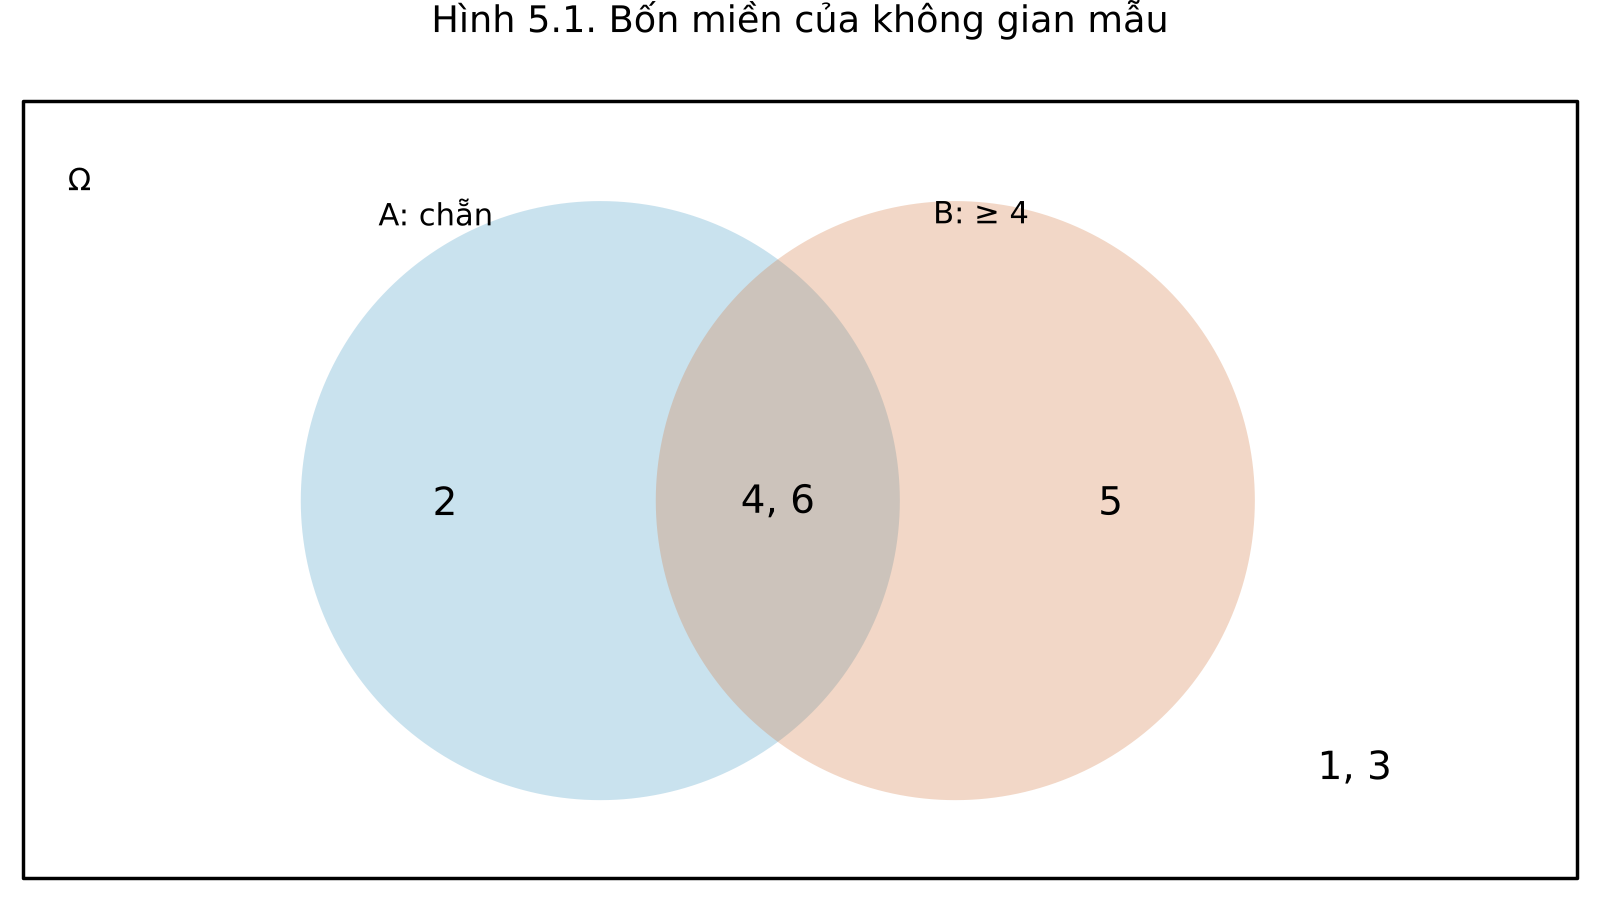

In [4]:
# Mỗi dòng là một đỉnh; group nối các đỉnh thành đúng một miền.
theta = np.linspace(0, 2*np.pi, 241)
circles = pd.concat([
    pd.DataFrame({"x": cx + 1.35*np.cos(theta),
                  "y": 1.7 + 1.35*np.sin(theta), "Biến cố": name})
    for cx, name in [(2.6, "A"), (4.2, "B")]
], ignore_index=True)
frame = pd.DataFrame({"x": [0, 7, 7, 0], "y": [0, 0, 3.5, 3.5]})
region_labels = pd.DataFrame({"x": [1.9, 3.4, 4.9, 6.0], "y": [1.7, 1.7, 1.7, 0.5],
                              "label": ["2", "4, 6", "5", "1, 3"]})
set_labels = pd.DataFrame({"x": [1.6, 4.1, 0.2], "y": [3.0, 3.0, 3.15],
                           "label": ["A: chẵn", "B: ≥ 4", "Ω"]})
venn_plot = (
    p9.ggplot()
    + p9.geom_polygon(frame, p9.aes("x", "y"), fill=None, color="black", size=0.7)
    + p9.geom_polygon(circles, p9.aes("x", "y", group="Biến cố", fill="Biến cố"),
                      alpha=0.30, color=None)
    + p9.scale_fill_manual(values={"A": "#4C9FC7", "B": "#D57B43"})
    + p9.geom_text(region_labels, p9.aes("x", "y", label="label"), size=14)
    + p9.geom_text(set_labels, p9.aes("x", "y", label="label"), ha="left", size=11)
    + p9.coord_fixed(xlim=(-0.1, 7.1), ylim=(-0.1, 3.7), expand=False)
    + p9.labs(title="Hình 5.1. Bốn miền của không gian mẫu")
    + p9.theme_void()
    + p9.theme(figure_size=(8, 4.5), legend_position="none")
)
display(venn_plot)


![Hình 5.S4. Hợp và giao trên sơ đồ Venn](figures/04_stat20_venn_union_intersection.png)

*Hình 5.S4.* Vùng thuộc ít nhất một hình tròn là hợp; phần chồng lên nhau là giao. Nếu đếm riêng từng hình tròn rồi cộng, vùng giao bị đếm hai lần. Mục 3 dùng nhận xét này để có quy tắc cộng.
*Nguồn ảnh: bản dịch STAT 20, §3.1.4 Biểu đồ Venn.*

### W05-BT01: Một phép thử có hai nhánh

Tung đồng xu cân đối. Nếu lần đầu ngửa H thì tung thêm một lần; nếu sấp T thì gieo một xúc xắc cân đối. Lần thứ hai độc lập với lần đầu trong mỗi nhánh. Ghi kết quả theo thứ tự.

1. Liệt kê không gian mẫu và các nhánh.
2. Các kết quả cuối có đồng khả năng không?

<details><summary>Đáp án và lập luận — W05-BT01</summary>

*Câu 1.* Nhánh H dẫn tới HH hoặc HT. Nhánh T dẫn tới T1, T2, …, T6. Vậy
$$\Omega=\{HH,HT,T1,T2,T3,T4,T5,T6\},$$
gồm 8 kết quả.

*Câu 2.* Tính xác suất từng kết quả bằng cách nhân dọc nhánh (quy tắc nhân, mục 4):

- $P(HH)=P(HT)=\frac12\cdot\frac12=\frac14$;
- $P(Tj)=\frac12\cdot\frac16=\frac1{12}$ với $j=1,\ldots,6$.

Kiểm tra tổng: $2\cdot\frac14+6\cdot\frac1{12}=1$.

Tám kết quả **không đồng khả năng**. Có 8 kết quả không có nghĩa mỗi kết quả có xác suất $\frac18$.

</details>

### Xung khắc, đối nhau và De Morgan

Hai biến cố **xung khắc** nếu chúng không thể cùng xảy ra: $A\cap B=\varnothing$.

Hai biến cố **đối nhau** nếu chúng xung khắc **và** phủ hết không gian mẫu: $B=\overline{A}$. Khi đó lần nào cũng có đúng một trong hai xảy ra.

Đối nhau thì xung khắc, nhưng xung khắc chưa chắc đối nhau. Với một xúc xắc, $\{1\}$ và $\{2\}$ xung khắc nhưng không đối nhau, vì kết quả 3 không thuộc cái nào. Tương tự, hai mức chất lượng A và B của một linh kiện có thể xung khắc mà chưa đối nhau, vì linh kiện còn có thể ở mức C hoặc bị loại.

![Hình 5.S5. Hai biến cố xung khắc](figures/05_stat20_venn_disjoint.png)

*Hình 5.S5.* Hai hình tròn không chồng lên nhau: hai biến cố xung khắc. Chúng chưa phủ hết hình chữ nhật, nên không đối nhau.
*Nguồn ảnh: bản dịch STAT 20, §3.1.4 Biểu đồ Venn.*

**Định luật De Morgan** giúp dịch các câu phủ định:

$$
\overline{A\cup B}=\overline{A}\cap\overline{B},\qquad \overline{A\cap B}=\overline{A}\cup\overline{B}.
$$

Đọc thành lời:

- "Không phải (A hoặc B)" nghĩa là "không A **và** không B".
- "Không phải (A và B)" nghĩa là "không A **hoặc** không B".

Phủ định đổi "hoặc" thành "và", đổi "và" thành "hoặc". Vì vậy "không biến cố nào xảy ra" khác "không đồng thời xảy ra cả hai": câu sau vẫn cho phép một biến cố xảy ra.

*Ví dụ.* Với $A=\{2,4,6\}$, $B=\{4,5,6\}$: $A\cup B=\{2,4,5,6\}$, nên $\overline{A\cup B}=\{1,3\}$. Mặt khác $\overline{A}=\{1,3,5\}$ và $\overline{B}=\{1,2,3\}$, nên $\overline{A}\cap\overline{B}=\{1,3\}$. Hai cách cho cùng kết quả.

<details><summary><b>Vì sao?</b> Chứng minh định luật De Morgan</summary>

Lấy một kết quả $\omega$ bất kỳ.

*Đẳng thức thứ nhất.*

- $\omega\in\overline{A\cup B}$ nghĩa là $\omega$ không thuộc $A\cup B$.
- Tức là $\omega$ không thuộc $A$ **và** không thuộc $B$. (Nếu thuộc một trong hai thì đã thuộc hợp.)
- Tức là $\omega\in\overline{A}\cap\overline{B}$.

Mỗi bước đi được theo cả hai chiều, nên hai tập có đúng cùng các phần tử.

*Đẳng thức thứ hai.*

- $\omega\in\overline{A\cap B}$ nghĩa là $\omega$ không thuộc cả hai cùng lúc.
- Tức là $\omega$ thiếu ít nhất một trong hai: $\omega\notin A$ **hoặc** $\omega\notin B$.
- Tức là $\omega\in\overline{A}\cup\overline{B}$. $\blacksquare$

</details>

### Từ lời sang ký hiệu

Phần lớn khó khăn của tuần này nằm ở bước dịch câu nói sang ký hiệu. Ví dụ: $A$ là "bạn An đi học muộn", $B$ là "bạn Bình đi học muộn".

| Lời nói | Ký hiệu | Ghi chú |
|---|---|---|
| ít nhất một bạn đi muộn | $A\cup B$ | "hoặc" bao gồm cả hai |
| cả hai bạn đi muộn | $A\cap B$ | |
| không bạn nào đi muộn | $\overline{A}\cap\overline{B}=\overline{A\cup B}$ | phủ định của "ít nhất một" |
| không đồng thời cả hai đi muộn | $\overline{A\cap B}=\overline{A}\cup\overline{B}$ | vẫn cho phép **một** bạn đi muộn |
| chỉ An đi muộn | $A\cap\overline{B}=A\setminus B$ | |
| đúng một bạn đi muộn | $(A\cap\overline{B})\cup(\overline{A}\cap B)$ | hai mảnh rời nhau |
| nhiều nhất một bạn đi muộn | $\overline{A\cap B}$ | trùng với "không đồng thời cả hai" |

Mẹo kiểm tra: vẽ sơ đồ Venn, tô vùng ứng với câu nói, rồi so với vùng mà ký hiệu chỉ ra.

### W05-Q02 — Mức độ 1: Xung khắc hay đối nhau?

Một vé hỗ trợ nhận đúng một mức: thấp, trung bình, cao, khẩn cấp. A: vé mức thấp; B: vé mức cao.

A. Độc lập và đối nhau.
B. Xung khắc nhưng không đối nhau.
C. Đối nhau nhưng không xung khắc.
D. Không xung khắc.

<details><summary>Đáp án và lập luận — W05-Q02</summary>

**Đáp án B.**

*Bước 1: có xung khắc không?* Mỗi vé nhận đúng một mức, nên không vé nào vừa thấp vừa cao: $A\cap B=\varnothing$. Vậy $A$ và $B$ xung khắc; loại D.

*Bước 2: có đối nhau không?* Phần bù của $A$ là "không thấp", gồm trung bình, cao và khẩn cấp. $B$ chỉ là "cao", nên $B\ne\overline{A}$. Hai biến cố không đối nhau; loại A và C.

Phương án C còn sai ở chỗ: đối nhau luôn kéo theo xung khắc.

</details>

### W05-EX01 — Mức độ 2: Hai máy chủ

A: máy chủ 1 gặp sự cố trong ngày; B: máy chủ 2 gặp sự cố. Biểu diễn: (1) ít nhất một máy chủ gặp sự cố; (2) cả hai hoạt động bình thường; (3) không đồng thời xảy ra hai sự cố; (4) chỉ máy chủ 1 gặp sự cố.

<details><summary>Đáp án và lập luận — W05-EX01</summary>

1. *Ít nhất một máy gặp sự cố:* $A\cup B$.
2. *Cả hai hoạt động bình thường:* máy 1 không sự cố **và** máy 2 không sự cố, tức $\overline{A}\cap\overline{B}$. Theo De Morgan, đó là $\overline{A\cup B}$, phủ định của câu 1.
3. *Không đồng thời xảy ra hai sự cố:* phủ định của "cả hai sự cố", tức $\overline{A\cap B}$. Theo De Morgan, đó là $\overline{A}\cup\overline{B}$.
4. *Chỉ máy chủ 1 gặp sự cố:* máy 1 sự cố và máy 2 không, tức $A\cap\overline{B}=A\setminus B$.

Câu 2 và câu 3 khác nhau. Câu 3 còn cho phép **đúng một** máy gặp sự cố; câu 2 thì không.

</details>

### W05-BT02: Ba nhà máy

$A_i$: nhà máy tại địa điểm $i$ hoàn thành đúng hạn, $i=1,2,3$. Biểu diễn (1) ít nhất một; (2) cả ba; (3) chỉ nhà máy 1; (4) đúng một nhà máy hoàn thành đúng hạn.

<details><summary>Đáp án và lập luận — W05-BT02</summary>

1. *Ít nhất một:* $A_1\cup A_2\cup A_3$.
2. *Cả ba:* $A_1\cap A_2\cap A_3$.
3. *Chỉ nhà máy 1:* nhà máy 1 đúng hạn, hai nhà máy kia không: $A_1\cap\overline{A_2}\cap\overline{A_3}$.
4. *Đúng một nhà máy:* nhà máy đúng hạn có thể là 1, 2 hoặc 3. Viết từng trường hợp như câu 3, rồi lấy hợp:
$$(A_1\cap\overline{A_2}\cap\overline{A_3})\cup(\overline{A_1}\cap A_2\cap\overline{A_3})\cup(\overline{A_1}\cap\overline{A_2}\cap A_3).$$

Ba trường hợp ở câu 4 đôi một xung khắc, vì mỗi trường hợp chỉ rõ nhà máy nào đúng hạn. Viết bằng ký hiệu không cần giả định các nhà máy độc lập.

</details>

## 3. Từ tập kết quả đến xác suất

### Ba tiên đề

Xác suất $P(A)$ gán cho mỗi biến cố $A$ một con số, đo khả năng $A$ xảy ra trong mô hình. Các con số đó phải thỏa ba **tiên đề**:

1. $P(A)\ge0$ với mọi biến cố $A$;
2. $P(\Omega)=1$;
3. nếu $A_1,A_2,\ldots$ đôi một xung khắc thì $P\left(\bigcup_i A_i\right)=\sum_i P(A_i)$.

Đọc tiên đề 3: nếu các biến cố không bao giờ cùng xảy ra, xác suất để một trong số chúng xảy ra bằng tổng các xác suất.

Ba tiên đề hợp lý nếu ta nghĩ xác suất là tỉ lệ số lần biến cố xảy ra khi lặp lại phép thử rất nhiều lần:

- một tỉ lệ không thể âm (tiên đề 1);
- lần nào cũng có một kết quả nào đó, nên $\Omega$ xảy ra 100% số lần (tiên đề 2);
- nếu hai biến cố không bao giờ cùng xảy ra, số lần "một trong hai xảy ra" bằng tổng số lần của từng cái (tiên đề 3).

Tiên đề 3 áp dụng cho một dãy hữu hạn hoặc vô hạn đếm được các biến cố. Với không gian mẫu hữu hạn, chỉ cần dạng cho hai biến cố: nếu $A\cap B=\varnothing$ thì $P(A\cup B)=P(A)+P(B)$. Dạng vô hạn sẽ cần ở Tuần 06, với phân phối Poisson.

### Các hệ quả

Từ ba tiên đề suy ra được các quy tắc dưới. Mọi chứng minh đều dùng một mẹo: **cắt biến cố thành các mảnh rời nhau, rồi dùng tiên đề 3.**

| Hệ quả | Đọc thành lời | Ví dụ với xúc xắc cân đối |
|---|---|---|
| $P(\varnothing)=0$ | biến cố không thể xảy ra có xác suất 0 | |
| $P(\overline{A})=1-P(A)$ | xác suất không xảy ra bằng 1 trừ xác suất xảy ra | $P(\text{không ra }6)=1-\frac16=\frac56$ |
| $0\le P(A)\le1$ | xác suất nằm giữa 0 và 1 | |
| nếu $A\subseteq B$ thì $P(A)\le P(B)$ | biến cố "rộng hơn" không thể ít khả năng hơn | $P(\text{ra }6)\le P(\text{ra số chẵn})$ |
| $P(A\setminus B)=P(A)-P(A\cap B)$ | bỏ phần chung khỏi $A$ | $P(\{2\})=\frac36-\frac26=\frac16$ |

Quy tắc phần bù hữu ích nhất khi biến cố cần tính có nhiều trường hợp, còn phần bù của nó chỉ có ít. Điển hình là câu "ít nhất một". Ví dụ: tung đồng xu cân đối 3 lần, xác suất có ít nhất một mặt sấp là $1-P(\text{không có mặt sấp nào})=1-\frac18=\frac78$.

<details><summary><b>Vì sao?</b> Chứng minh năm hệ quả</summary>

*(a) $P(\varnothing)=0$.* $\Omega$ và $\varnothing$ rời nhau, và $\Omega\cup\varnothing=\Omega$. Theo tiên đề 3: $P(\Omega)=P(\Omega)+P(\varnothing)$. Trừ $P(\Omega)$ ở hai vế được $P(\varnothing)=0$.

*(b) Quy tắc phần bù.* $A$ và $\overline{A}$ rời nhau, và $A\cup\overline{A}=\Omega$. Theo tiên đề 3 rồi tiên đề 2: $P(A)+P(\overline{A})=P(\Omega)=1$.

*(c) $0\le P(A)\le1$.* Theo tiên đề 1, $P(A)\ge0$. Theo (b), $P(A)=1-P(\overline{A})$, mà $P(\overline{A})\ge0$, nên $P(A)\le1$.

*(d) Tính đơn điệu.* Giả sử $A\subseteq B$. Cắt $B$ thành hai mảnh rời nhau: $A$ và $B\setminus A$. Theo tiên đề 3: $P(B)=P(A)+P(B\setminus A)$. Vì $P(B\setminus A)\ge0$ nên $P(B)\ge P(A)$.

*(e) Quy tắc hiệu.* Cắt $A$ thành hai mảnh rời nhau: phần cũng thuộc $B$ ($A\cap B$) và phần không thuộc $B$ ($A\setminus B$). Theo tiên đề 3: $P(A)=P(A\cap B)+P(A\setminus B)$. Chuyển vế được kết quả. $\blacksquare$

</details>

### Khi các kết quả đồng khả năng

Nếu $\Omega$ hữu hạn và mọi kết quả **đồng khả năng** (có cùng xác suất), thì

$$P(A)=\frac{\lvert A\rvert}{\lvert\Omega\rvert}.$$

Đọc là: xác suất của $A$ bằng số kết quả thuận lợi chia cho tổng số kết quả. Ở đây $\lvert A\rvert$ là số phần tử của $A$.

*Ví dụ.* Với xúc xắc cân đối, $P(\text{số chẵn})=\frac{\lvert\{2,4,6\}\rvert}{6}=\frac36$. Biến cố "số chẵn và không nhỏ hơn 4" là $A\cap B=\{4,6\}$, nên $P(A\cap B)=\frac26$.

<details><summary><b>Vì sao?</b> Chứng minh công thức đếm</summary>

*Bước 1.* Có $n=\lvert\Omega\rvert$ kết quả, mỗi kết quả có cùng xác suất $q$.

*Bước 2.* Các kết quả đơn lẻ rời nhau và hợp lại thành $\Omega$. Theo tiên đề 3 và 2: $nq=1$, tức $q=\frac1n$.

*Bước 3.* Biến cố $A$ là hợp của $\lvert A\rvert$ kết quả rời nhau. Theo tiên đề 3: $P(A)=\lvert A\rvert\cdot\frac1n$. $\blacksquare$

</details>

**Điều kiện đồng khả năng là bắt buộc.** Hai phản ví dụ:

- *Tổng hai xúc xắc.* Liệt kê $\Omega=\{2,3,\ldots,12\}$ thì có 11 kết quả, nhưng chúng không đồng khả năng: tổng 7 có 6 cách tạo ra, tổng 2 chỉ có 1 cách. Muốn đếm, phải liệt kê 36 cặp có thứ tự $(i,j)$.
- *W05-BT01.* Không gian mẫu có 8 kết quả, nhưng $P(HH)=\frac14$ còn $P(T1)=\frac1{12}$.

Cùng một phép thử có thể có cấp kết quả đồng khả năng và cấp không. Ba hình sau là ba ví dụ; chúng cũng chuẩn bị cho Tuần 06.

![Hình 5.S6. Hộp năm vé: phân biệt vé với giá trị](figures/06_stat20_number_tickets_box.jpg)

*Hình 5.S6.* Hộp có năm vé $[1, 2, 2, 3, 4]$. Rút ngẫu nhiên một vé thì mỗi **vé** có xác suất $\frac15$. Nhưng **giá trị** 2 nằm trên hai vé, nên có xác suất $\frac25$. Có bốn giá trị khác nhau không có nghĩa mỗi giá trị có xác suất $\frac14$.
*Nguồn ảnh: bản dịch STAT 20, §3.1.5.2 Một hộp vé.*

![Hình 5.S7. Đồng xu thiên vị bằng hộp H, H, T](figures/07_stat20_biased_coin_tree.png)

*Hình 5.S7.* Một đồng xu thiên vị có $P(H)=\frac23$, $P(T)=\frac13$. Ta biểu diễn nó bằng hộp ba vé $[H, H, T]$: các **vé** đồng khả năng, dù các **mặt** thì không. Rút hai lần có hoàn lại: 9 cặp vé đồng khả năng, nhưng các chuỗi mặt HH, HT, TH, TT có xác suất $\frac49$, $\frac29$, $\frac29$, $\frac19$.
*Nguồn ảnh: bản dịch STAT 20, §3.1.5.3 Tung một đồng xu thiên vị.*

![Hình 5.S8. Roulette và xác suất đỏ](figures/08_stat20_roulette_wheel.jpg)

*Hình 5.S8.* Bánh xe roulette kiểu Mỹ có 38 ô: 18 đỏ, 18 đen, 2 xanh. Các **ô** đồng khả năng, nên $P(\text{đỏ})=\frac{18}{38}\approx0{,}47$, không phải $\frac12$. Trước khi dùng mô hình, hãy kiểm tra số ô của đúng loại bánh xe.
*Nguồn ảnh: bản dịch STAT 20, §3.1.5.4 Đặt cược vào màu đỏ trong trò roulette.*

### Xác suất và tần suất

Lặp lại phép thử độc lập trong cùng điều kiện, **tần suất tương đối** (tỉ lệ số lần biến cố xảy ra) có xu hướng ổn định quanh xác suất khi số lần lặp tăng. Mục 5 sẽ thấy điều này với trò De Méré. Ổn định không có nghĩa là đi thẳng về đích: một đoạn tần suất lên cao không buộc đoạn sau phải đi xuống.

**Code.** Ô dưới tính xác suất bằng công thức đếm.

- `len(event) / len(omega)` là $\lvert A\rvert/\lvert\Omega\rvert$ cho từng biến cố đã liệt kê ở mục 2.
- Phần thứ hai dùng hộp vé $[0, 0, 1, 2]$. `value_counts(normalize=True)` đếm mỗi giá trị nằm trên bao nhiêu vé, rồi chia cho tổng số vé.

**Bạn đoán trước:** trong hộp $[0, 0, 1, 2]$, giá trị 0 có xác suất bao nhiêu?

In [5]:
event_probabilities = pd.Series({name: len(event) / len(omega)
                                for name, event in events.items()}, name="Xác suất")
display(event_probabilities.to_frame())
ticket_values = np.array([0, 0, 1, 2])
display(pd.Series(ticket_values).value_counts(normalize=True).sort_index().rename("P(giá trị)").to_frame())

,Xác suất
A hợp B,0.666667
A giao B,0.333333
Phần bù A,0.500000
A trừ B,0.166667


,P(giá trị)
0,0.50
1,0.25
2,0.25


Bảng đầu: $P(A\cup B)=\frac46$, $P(A\cap B)=\frac26$, $P(\overline{A})=\frac36$, $P(A\setminus B)=\frac16$. Bảng sau: hộp $[0,0,1,2]$ cho $P(0)=\frac12$ và $P(1)=P(2)=\frac14$. Bốn vé đồng khả năng, nhưng ba giá trị thì không.

### Quy tắc cộng tổng quát

Hình 5.S4 cho thấy: cộng $P(A)$ với $P(B)$ thì phần giao $A\cap B$ bị tính hai lần. Trừ đi một lần, ta được **quy tắc cộng**:

$$P(A\cup B)=P(A)+P(B)-P(A\cap B).$$

Đọc là: xác suất ít nhất một trong hai xảy ra bằng tổng hai xác suất, trừ phần chung. Khi $A$, $B$ xung khắc thì $P(A\cap B)=0$, và ta trở lại tiên đề 3.

![Hình 5.S20. Vì sao quy tắc cộng phải trừ phần giao](figures/20_stat20_inclusion_exclusion_venn.png)

*Hình 5.S20.* Hai lớp gạch chéo cùng phủ vùng giao. Trừ một lần $P(A\cap B)$ để mỗi kết quả của hợp được tính đúng một lần.
*Nguồn ảnh: bản dịch STAT 20, §3.3.9 Bao hàm–loại trừ (quy tắc cộng tổng quát).*

*Ví dụ giải tay.* Gieo xúc xắc cân đối, $A=\{2,4,6\}$, $B=\{4,5,6\}$.

1. $P(A)=\frac36$, $P(B)=\frac36$, $P(A\cap B)=P(\{4,6\})=\frac26$.
2. $P(A\cup B)=\frac36+\frac36-\frac26=\frac46$.
3. Kiểm tra bằng đếm: $A\cup B=\{2,4,5,6\}$ có 4 phần tử, đúng $\frac46$.

<details><summary><b>Vì sao?</b> Chứng minh quy tắc cộng</summary>

*Bước 1.* Cắt $A\cup B$ thành hai mảnh rời nhau: $A$, và phần thuộc $B$ nhưng không thuộc $A$, tức $B\setminus A$.

*Bước 2.* Theo tiên đề 3: $P(A\cup B)=P(A)+P(B\setminus A)$.

*Bước 3.* Theo quy tắc hiệu (hệ quả e), đổi vai trò $A$ và $B$: $P(B\setminus A)=P(B)-P(A\cap B)$.

*Bước 4.* Thay bước 3 vào bước 2. $\blacksquare$

</details>

**Ba biến cố.** Cùng cách sửa đếm lặp (nguyên lý bao hàm–loại trừ) cho:

$$P(A\cup B\cup C)=P(A)+P(B)+P(C)-P(A\cap B)-P(A\cap C)-P(B\cap C)+P(A\cap B\cap C).$$

*Ví dụ.* Thêm $C=\{2,3,5\}$ (số nguyên tố). Mỗi biến cố có xác suất $\frac36$. Các giao: $A\cap B=\{4,6\}$, $A\cap C=\{2\}$, $B\cap C=\{5\}$, $A\cap B\cap C=\varnothing$. Công thức cho $\frac96-\frac46+0=\frac56$. Đếm trực tiếp: $A\cup B\cup C=\{2,3,4,5,6\}$, đúng $\frac56$.

<details><summary><b>Vì sao?</b> Chứng minh công thức cho ba biến cố</summary>

*Bước 1.* Coi $A\cup B$ là một biến cố, áp dụng quy tắc hai biến cố cho $A\cup B$ và $C$:
$$P(A\cup B\cup C)=P(A\cup B)+P(C)-P\big((A\cup B)\cap C\big).$$

*Bước 2.* Khai triển $P(A\cup B)=P(A)+P(B)-P(A\cap B)$.

*Bước 3.* Ta có $(A\cup B)\cap C=(A\cap C)\cup(B\cap C)$, và giao của hai mảnh này là $A\cap B\cap C$. Áp dụng quy tắc hai biến cố một lần nữa:
$$P\big((A\cup B)\cap C\big)=P(A\cap C)+P(B\cap C)-P(A\cap B\cap C).$$

*Bước 4.* Thay bước 2 và bước 3 vào bước 1. $\blacksquare$

</details>

### Hệ quả: tổng các xác suất chỉ là chặn trên

Vì $P(A\cap B)\ge0$, quy tắc cộng cho

$$P(A\cup B)\le P(A)+P(B).$$

Áp dụng nhiều lần, điều này đúng với nhiều biến cố. **Đây chính là chỗ De Méré sai.** Con số $4\cdot\frac16$ chỉ là chặn trên của xác suất "ít nhất một mặt 6", vì các biến cố "ra 6 ở lần $i$" có thể cùng xảy ra. Với 2 lần gieo: $\frac16+\frac16=\frac{12}{36}$, nhưng xác suất đúng là $\frac{11}{36}$, vì kết quả $(6,6)$ bị tính hai lần. Gieo 7 lần thì tổng $7\cdot\frac16$ còn vượt quá 1.

### Ví dụ: 137 hộ gia đình

Một khảo sát gồm 137 hộ. Các ô của bảng trong ô code dưới là số đếm của bài toán. Chọn ngẫu nhiên một hộ; $I$ là "hộ dùng Internet", $T$ là "hộ dùng truyền hình". Có 86 hộ dùng Internet, 107 hộ dùng truyền hình, 69 hộ dùng cả hai và 13 hộ không dùng dịch vụ nào.

**Bạn đoán trước:** khoảng bao nhiêu phần trăm số hộ dùng ít nhất một dịch vụ?

Giải tay:

1. $P(I)=\frac{86}{137}$, $P(T)=\frac{107}{137}$, $P(I\cap T)=\frac{69}{137}$.
2. Quy tắc cộng: $P(I\cup T)=\frac{86+107-69}{137}=\frac{124}{137}\approx0{,}9051$.
3. Kiểm tra bằng phần bù: "không dùng dịch vụ nào" là $\overline{I}\cap\overline{T}=\overline{I\cup T}$, gồm 13 hộ. Vậy $P(I\cup T)=1-\frac{13}{137}=\frac{124}{137}$.

Ô code tính lại theo hai cách. `households.loc["Có Internet"].sum()` cộng hàng "Có Internet" (86 hộ); `households["Có truyền hình"].sum()` cộng cột "Có truyền hình" (107 hộ).

In [6]:
households = pd.DataFrame([[13, 38], [17, 69]],
                          index=["Không Internet", "Có Internet"],
                          columns=["Không truyền hình", "Có truyền hình"])
display(households)
total = households.to_numpy().sum()
p_internet = households.loc["Có Internet"].sum() / total
p_tv = households["Có truyền hình"].sum() / total
p_both = households.loc["Có Internet", "Có truyền hình"] / total
p_either = p_internet + p_tv - p_both
print(f"P(I hoặc T) = {p_either:.6f}; kiểm tra bằng phần bù = {1 - 13 / total:.6f}")

,Không truyền hình,Có truyền hình
Không Internet,13,38
Có Internet,17,69


P(I hoặc T) = 0.905109; kiểm tra bằng phần bù = 0.905109


## 4. Xác suất có điều kiện, quy tắc nhân và độc lập

### Biết thêm thông tin thì mẫu số đổi

Quay lại 137 hộ. Giả sử bạn biết hộ được chọn **có Internet**. Khả năng hộ đó dùng truyền hình là bao nhiêu?

Biết hộ có Internet, ta chỉ còn xét 86 hộ của hàng "Có Internet". Trong 86 hộ đó, 69 hộ dùng truyền hình. Câu trả lời là $\frac{69}{86}\approx0{,}80$, lớn hơn $\frac{107}{137}\approx0{,}78$ khi chưa biết gì.

Con số này gọi là **xác suất có điều kiện** của $T$ khi biết $I$, viết $P(T\mid I)$, đọc là *xác suất của T khi biết I*. Định nghĩa chung:

$$P(A\mid B)=\frac{P(A\cap B)}{P(B)},\qquad P(B)>0.$$

Đọc thành lời: trong những lần $B$ xảy ra, tỉ lệ lần $A$ cũng xảy ra.

- $B$ là thông tin đã biết. Nó quyết định **mẫu số**, tức nhóm tham chiếu.
- Tử số chỉ giữ các kết quả vừa thuộc $A$ vừa thuộc $B$.
- Nếu $P(B)=0$ thì phép chia không xác định.

Khi các kết quả đồng khả năng, định nghĩa trùng với cách đếm "trong $B$, có bao nhiêu kết quả thuộc $A$":
$$P(A\mid B)=\frac{\lvert A\cap B\rvert/\lvert\Omega\rvert}{\lvert B\rvert/\lvert\Omega\rvert}=\frac{\lvert A\cap B\rvert}{\lvert B\rvert}.$$

Mẹo: trước khi tính, hỏi "mẫu số là nhóm nào?". Mẫu số luôn là biến cố đứng **sau** dấu $\mid$.

![Hình 5.S15. Đảo chiều điều kiện đổi mẫu số](figures/15_stat20_conditional_probability_direction.png)

*Hình 5.S15.* $B$ nhỏ và gần như nằm trọn trong $A$. Vì vậy $P(A\mid B)$ gần 1, còn $P(B\mid A)$ nhỏ. Hai xác suất có cùng tử số là phần giao, nhưng mẫu số lần lượt là $P(B)$ và $P(A)$. Diện tích ở đây chỉ giúp trực giác, không thay cho số liệu.
*Nguồn ảnh: bản dịch STAT 20, §3.3.4 Công thức nhân: tính xác suất của một giao.*

<details><summary><b>Vì sao?</b> Xác suất có điều kiện cũng là một xác suất</summary>

Cố định $B$ với $P(B)>0$. Hàm $A\mapsto P(A\mid B)$ thỏa cả ba tiên đề.

1. *Không âm.* $P(A\cap B)\ge0$ và $P(B)>0$, nên thương không âm.
2. *Toàn bộ bằng 1.* $P(\Omega\mid B)=P(\Omega\cap B)/P(B)=P(B)/P(B)=1$.
3. *Cộng tính.* Nếu $A_1$, $A_2$ rời nhau thì $A_1\cap B$ và $A_2\cap B$ cũng rời nhau, và $(A_1\cup A_2)\cap B=(A_1\cap B)\cup(A_2\cap B)$. Do đó
$$P(A_1\cup A_2\mid B)=\frac{P(A_1\cap B)+P(A_2\cap B)}{P(B)}=P(A_1\mid B)+P(A_2\mid B).$$

Vì vậy mọi quy tắc ở mục 3 vẫn đúng khi thêm "$\mid B$" vào mọi chỗ, ví dụ $P(\overline{A}\mid B)=1-P(A\mid B)$. $\blacksquare$

Lưu ý: quy tắc phần bù áp dụng cho biến cố đứng **trước** dấu $\mid$, không áp dụng cho điều kiện. Nói chung $P(A\mid\overline{B})\ne1-P(A\mid B)$.

</details>

### W05-EX02 — Mức độ 2: Hai chiều điều kiện

Từ bảng 137 hộ, 86 hộ có Internet, 107 hộ có truyền hình và 69 hộ có cả hai. Tính $P(T\mid I)$ và $P(I\mid T)$. Chúng có bằng nhau không?

<details><summary>Đáp án và lập luận — W05-EX02</summary>

*$P(T\mid I)$.* Điều kiện là $I$, nên mẫu số là 86 hộ có Internet. Tử số là 69 hộ có cả hai. Vậy $P(T\mid I)=\frac{69}{86}\approx0{,}8023$.

*$P(I\mid T)$.* Điều kiện là $T$, nên mẫu số là 107 hộ có truyền hình. Vậy $P(I\mid T)=\frac{69}{107}\approx0{,}6449$.

Hai xác suất không bằng nhau. Cùng tử số 69 nhưng khác mẫu số, nên chúng trả lời hai câu hỏi khác nhau.

</details>

### Xác suất có điều kiện bằng cách lọc

Gieo hai xúc xắc cân đối. Biết hai mặt **khác nhau**, xác suất có ít nhất một mặt 6 là bao nhiêu?

**Bạn đoán trước:** đếm tay xem còn bao nhiêu cặp sau khi bỏ các cặp giống nhau, và trong đó có bao nhiêu cặp có mặt 6.

Ô code làm đúng như cách đếm tay.

- `product(range(1, 7), repeat=2)` liệt kê 36 cặp có thứ tự $(1,1),(1,2),\ldots,(6,6)$. Mỗi hàng của `dice_pairs` là một kết quả đồng khả năng.
- Cột `different` là biến cố "hai mặt khác nhau"; cột `at_least_one_six` là "có ít nhất một mặt 6". Cả hai là cột đúng/sai.
- `dice_pairs.loc[dice_pairs["different"]]` **lọc**, chỉ giữ các hàng có hai mặt khác nhau. Đây chính là bước thu hẹp tập tham chiếu.
- `.mean()` trên cột đúng/sai của bảng đã lọc cho tỉ lệ $\lvert A\cap B\rvert/\lvert B\rvert$.

In [7]:
dice_pairs = pd.DataFrame(list(product(range(1, 7), repeat=2)), columns=["die1", "die2"])
dice_pairs["different"] = dice_pairs["die1"] != dice_pairs["die2"]
dice_pairs["at_least_one_six"] = (dice_pairs["die1"] == 6) | (dice_pairs["die2"] == 6)
conditional_pairs = dice_pairs.loc[dice_pairs["different"]]
print("Kết quả có hai mặt khác nhau:", len(conditional_pairs))
print("Trong đó có ít nhất một 6:", conditional_pairs["at_least_one_six"].sum())
print("P(ít nhất một 6 | khác nhau) =", conditional_pairs["at_least_one_six"].mean())

Kết quả có hai mặt khác nhau: 30
Trong đó có ít nhất một 6: 10
P(ít nhất một 6 | khác nhau) = 0.3333333333333333


Còn 30 cặp có hai mặt khác nhau. Trong đó 10 cặp có mặt 6, nên xác suất có điều kiện là $\frac{10}{30}=\frac13$.

Cặp $(6,6)$ có mặt 6 nhưng đã bị loại khỏi tập tham chiếu. Lấy cả 11 cặp có mặt 6 rồi chia cho 30 là dùng sai tử số.

### W05-BT04: Hai xúc xắc có số chấm khác nhau

Gieo hai xúc xắc cân đối độc lập, phân biệt xúc xắc 1 và 2. Biết hai số chấm khác nhau, tính xác suất ít nhất một mặt 6. Gọi A là có ít nhất một 6, B là hai số khác nhau; xác định B và A giao B trước khi tính.

<details><summary>Đáp án và lập luận — W05-BT04</summary>

*Bước 1.* $\Omega$ gồm 36 cặp có thứ tự, đồng khả năng.

*Bước 2.* $B$: hai số khác nhau. Có 6 cặp giống nhau, nên $\lvert B\rvert=36-6=30$.

*Bước 3.* $A\cap B$: có mặt 6 và hai số khác nhau. Đó là các cặp $(6,j)$ với $j=1,\ldots,5$ và $(i,6)$ với $i=1,\ldots,5$, nên $\lvert A\cap B\rvert=10$. Cặp $(6,6)$ không thuộc $B$.

*Bước 4.* $P(A\mid B)=\dfrac{10/36}{30/36}=\dfrac{10}{30}=\dfrac13$.

</details>

### Quy tắc nhân

Nhân hai vế của định nghĩa $P(B\mid A)=P(A\cap B)/P(A)$ với $P(A)$, ta được **quy tắc nhân**:

$$P(A\cap B)=P(A)\,P(B\mid A)=P(B)\,P(A\mid B).$$

Đọc là: xác suất cả hai xảy ra bằng xác suất bước đầu, nhân với xác suất bước sau **khi bước đầu đã xảy ra**.

Với ba biến cố:

$$P(A\cap B\cap C)=P(A)\,P(B\mid A)\,P(C\mid A\cap B).$$

Điều kiện ở bước thứ ba chứa cả hai bước trước. Công thức cần các biến cố làm điều kiện có xác suất dương.

![Hình 5.S14. Phần giao trong quy tắc nhân](figures/14_stat20_venn_intersection.png)

*Hình 5.S14.* Vùng tím là $A\cap B$. Có thể đi từ $P(A)$ rồi nhân $P(B\mid A)$, hoặc từ $P(B)$ rồi nhân $P(A\mid B)$. Cả hai cách cùng đo một vùng.
*Nguồn ảnh: bản dịch STAT 20, §3.3.4 Công thức nhân: tính xác suất của một giao.*

<details><summary><b>Vì sao?</b> Quy tắc nhân cho ba biến cố</summary>

*Bước 1.* Áp dụng quy tắc nhân cho hai biến cố $A\cap B$ và $C$:
$$P(A\cap B\cap C)=P(A\cap B)\,P(C\mid A\cap B).$$

*Bước 2.* Thay $P(A\cap B)=P(A)\,P(B\mid A)$ vào. $\blacksquare$

</details>

*Ví dụ giải tay.* Túi có 3 quân xanh và 7 quân khác. Rút 2 quân **không hoàn lại**. Tính xác suất cả hai quân đều xanh.

1. $P(\text{lần 1 xanh})=\frac3{10}$.
2. Biết lần 1 đã xanh, túi còn 2 xanh trong 9 quân: $P(\text{lần 2 xanh}\mid\text{lần 1 xanh})=\frac29$.
3. Quy tắc nhân: $P(\text{hai xanh})=\frac3{10}\cdot\frac29=\frac1{15}\approx0{,}067$.

Dùng $\left(\frac3{10}\right)^2=0{,}09$ là bỏ qua việc túi đã thay đổi sau lần rút đầu.

**Code.** Ô dưới kiểm tra bằng cách liệt kê, không mô phỏng. Đánh số các quân từ 0 đến 9; quân 0, 1, 2 là xanh.

- `product(range(10), repeat=2)` liệt kê 100 cặp (lần 1, lần 2). Một quân có thể ra hai lần, nên đây là rút **có hoàn lại**.
- `(ordered_draws < 3).all(axis=1)`: cả hai quân đều có số nhỏ hơn 3, tức đều xanh.
- `ordered_draws[:, 0] != ordered_draws[:, 1]` bỏ các cặp rút trùng một quân. Còn lại 90 cặp, ứng với rút **không hoàn lại**.

In [8]:
ordered_draws = np.array(list(product(range(10), repeat=2)))
blue_both = (ordered_draws < 3).all(axis=1)
no_replacement = ordered_draws[:, 0] != ordered_draws[:, 1]
print("Có hoàn lại:", blue_both.mean(), "= (3/10)^2")
print("Không hoàn lại:", blue_both[no_replacement].mean(), "= (3/10)(2/9)")

Có hoàn lại: 0.09 = (3/10)^2
Không hoàn lại: 0.06666666666666667 = (3/10)(2/9)


Kết quả: có hoàn lại cho $0{,}09=\left(\frac3{10}\right)^2$; không hoàn lại cho $0{,}0667\approx\frac3{10}\cdot\frac29=\frac1{15}$.

### Có hoàn lại và không hoàn lại

- Rút **có hoàn lại**: trả quân về rồi trộn lại. Thành phần túi không đổi, nên các lần rút độc lập.
- Rút **không hoàn lại**: thành phần túi thay đổi sau mỗi lần, nên các lần rút phụ thuộc nhau.

Bảng dưới so sánh hai cách với túi 3 xanh, 7 quân khác:

| | $P(\text{lần 2 xanh}\mid\text{lần 1 xanh})$ | $P(\text{lần 2 xanh})$ |
|---|---|---|
| Có hoàn lại | $3/10$ | $3/10$ |
| Không hoàn lại | $2/9$ | $3/10$ |

Cột cuối có thể gây bất ngờ. Rút không hoàn lại mà **chưa biết** lần 1 ra gì, xác suất lần 2 ra xanh vẫn là $\frac3{10}$. Thứ tự rút chỉ quan trọng khi ta biết kết quả các lần trước.

<details><summary><b>Vì sao?</b> Lần 2 ra xanh vẫn có xác suất 3/10</summary>

Chia theo kết quả lần 1 (xanh hoặc không xanh), dùng quy tắc nhân cho từng trường hợp, rồi cộng hai trường hợp xung khắc:
$$P(\text{lần 2 xanh})=\frac{3}{10}\cdot\frac29+\frac7{10}\cdot\frac39=\frac{6+21}{90}=\frac{3}{10}.$$
Cách "chia trường hợp, nhân, rồi cộng" này chính là công thức xác suất toàn phần ở mục 6.

</details>

STAT 20 minh họa bằng một hộp nhỏ hơn: 2 vé đỏ (R), 2 vé xanh (B).

![Hình 5.S10. Hộp hai vé đỏ, hai vé xanh](figures/10_stat20_red_blue_box.jpg)

*Hình 5.S10.* Gắn nhãn từng vé R1, R2, B1, B2. Nhãn giúp phân biệt các kết quả đồng khả năng; màu là thông tin ghi trên vé.
*Nguồn ảnh: bản dịch STAT 20, §3.3.2.1 Ví dụ: Rút các vé màu đỏ và xanh từ một hộp.*

![Hình 5.S11. Ba lần lấy có hoàn lại](figures/11_stat20_replacement_three_draws.jpg)

*Hình 5.S11.* Rút ba lần **có hoàn lại**. Hộp không đổi, mỗi lần đỏ hay xanh đều có xác suất $\frac12$. Tám chuỗi màu dài 3 đều có xác suất $\left(\frac12\right)^3=\frac18$.
*Nguồn ảnh: bản dịch STAT 20, §3.3.2.1.*

![Hình 5.S12. Ba lần lấy không hoàn lại](figures/12_stat20_without_replacement_three_draws.jpg)

*Hình 5.S12.* Rút ba lần **không hoàn lại**. Không thể có ba vé cùng màu, vì mỗi màu chỉ có hai vé. Sáu chuỗi màu còn lại đều có xác suất $\frac16$. Kết quả này phải kiểm tra từ các vé riêng biệt: không phải phép lấy không hoàn lại nào cũng cho các chuỗi màu đồng khả năng.
*Nguồn ảnh: bản dịch STAT 20, §3.3.2.1.*

![Hình 5.S13. Hai lần lấy không hoàn lại: cây thay đổi](figures/13_stat20_without_replacement_tree.jpg)

*Hình 5.S13.* Rút hai lần không hoàn lại. Nếu lần đầu ra xanh, hộp còn 2 đỏ và 1 xanh. Nhân dọc nhánh: RR, RB, BR, BB có xác suất $\frac16$, $\frac13$, $\frac13$, $\frac16$. Bốn chuỗi màu **không** đồng khả năng. (Một câu ở §3.3.3 của bản dịch ghi hộp còn hai vé xanh sau khi rút xanh; đúng ra chỉ còn một.)
*Nguồn ảnh: bản dịch STAT 20, §3.3.2.1.*

**Code.** Ô dưới kiểm tra các xác suất trên bằng cách liệt kê từng vé.

- `permutations(ticket_colors, draw_count)` liệt kê mọi cách rút `draw_count` vé khác nhau, có thứ tự, không hoàn lại. Mỗi cách là một kết quả đồng khả năng.
- `"".join(ticket_colors[t] for t in draw)` đổi một cách rút, ví dụ `("R1", "B2")`, thành chuỗi màu `"RB"`.
- `value_counts(normalize=True)` gom các cách rút theo chuỗi màu rồi tính tỉ lệ.

**Bạn đoán trước:** rút hai lần thì có mấy chuỗi màu, các chuỗi có đồng khả năng không? Rút ba lần thì sao?

In [9]:
from itertools import permutations
ticket_colors = {"R1": "R", "R2": "R", "B1": "B", "B2": "B"}
for draw_count in [2, 3]:
    labeled_outcomes = list(permutations(ticket_colors, draw_count))
    color_sequences = ["".join(ticket_colors[t] for t in draw) for draw in labeled_outcomes]
    print("Số lần lấy:", draw_count, "; số kết quả vé có thứ tự:", len(labeled_outcomes))
    display(pd.Series(color_sequences).value_counts(normalize=True).sort_index().rename("Xác suất").to_frame())

Số lần lấy: 2 ; số kết quả vé có thứ tự: 12


,Xác suất
BB,0.166667
BR,0.333333
RB,0.333333
RR,0.166667


Số lần lấy: 3 ; số kết quả vé có thứ tự: 24


,Xác suất
BBR,0.166667
BRB,0.166667
BRR,0.166667
RBB,0.166667
RBR,0.166667
RRB,0.166667


Rút hai lần: 12 cách rút vé; RR và BB có xác suất $\frac16$, RB và BR có xác suất $\frac13$. Rút ba lần: 24 cách rút vé; sáu chuỗi màu đều có xác suất $\frac16$. Khi nói "đồng khả năng", luôn ghi rõ đang xét cấp kết quả nào (vé hay màu) và cơ chế rút.

### Độc lập

Hai biến cố $A$ và $B$ **độc lập** khi

$$P(A\cap B)=P(A)\,P(B).$$

Nếu $P(B)>0$, điều này tương đương với

$$P(A\mid B)=P(A).$$

Đọc là: biết $B$ xảy ra không làm thay đổi khả năng xảy ra của $A$. Định nghĩa dạng tích được ưu tiên vì nó đối xứng giữa $A$ và $B$, và vẫn dùng được khi $P(B)=0$.

<details><summary><b>Vì sao?</b> Hai cách phát biểu tương đương</summary>

Giả sử $P(B)>0$. Chia hai vế của $P(A\cap B)=P(A)P(B)$ cho $P(B)$:
$$\frac{P(A\cap B)}{P(B)}=P(A),\quad\text{tức là}\quad P(A\mid B)=P(A).$$
Mỗi bước đi được theo cả hai chiều. Tương tự, nếu $P(A)>0$ thì độc lập tương đương với $P(B\mid A)=P(B)$. $\blacksquare$

</details>

**Khi nào được giả định độc lập?** Các lần tung đồng xu thường được mô hình hóa là độc lập. Rút có hoàn lại và trộn lại cũng cho các lần rút độc lập. Rút không hoàn lại thường làm các lần rút phụ thuộc. Phải nêu rõ cơ chế; chỉ nhìn tên hai biến thì chưa đủ để kết luận độc lập.

**Phần bù của biến cố độc lập cũng độc lập.** Nếu $A$, $B$ độc lập thì các cặp $A$ và $\overline{B}$, $\overline{A}$ và $B$, $\overline{A}$ và $\overline{B}$ đều độc lập. Bài W05-CASE01 ở mục 7 dùng kết quả này.

<details><summary><b>Vì sao?</b> Phần bù của biến cố độc lập cũng độc lập</summary>

Chứng minh cho cặp $A$ và $\overline{B}$:
$$P(A\cap\overline{B})=P(A)-P(A\cap B)=P(A)-P(A)P(B)=P(A)\big(1-P(B)\big)=P(A)\,P(\overline{B}).$$

- Dấu bằng thứ nhất: quy tắc hiệu, vì $A\cap\overline{B}=A\setminus B$.
- Dấu bằng thứ hai: $A$ và $B$ độc lập.
- Dấu bằng cuối: quy tắc phần bù.

Áp dụng kết quả vừa chứng minh cho cặp $(B, A)$ được cặp $\overline{A}$ và $B$; áp dụng tiếp cho cặp $(\overline{A}, B)$ được cặp $\overline{A}$ và $\overline{B}$. $\blacksquare$

</details>

<details><summary><b>Đọc thêm</b> Nhiều biến cố độc lập</summary>

Các biến cố $A_1,\ldots,A_n$ **độc lập** khi tích xác suất đúng với **mọi nhóm con**: mọi cặp, mọi bộ ba, …, và cả $n$ biến cố. Độc lập từng đôi là chưa đủ.

*Phản ví dụ.* Tung 2 đồng xu cân đối. $A$: lần 1 ngửa; $B$: lần 2 ngửa; $C$: hai lần giống nhau. Mỗi biến cố có xác suất $\frac12$, mỗi giao của hai biến cố có xác suất $\frac14$, nên chúng độc lập từng đôi. Nhưng $P(A\cap B\cap C)=P(\text{ngửa–ngửa})=\frac14\ne\frac18$. Biết $A$ và $B$ đã xảy ra thì chắc chắn $C$ xảy ra.

Bài toán De Méré cần độc lập theo nghĩa đầy đủ này cho cả 4 (hoặc 24) lần gieo.

</details>

### Kiểm tra độc lập trong một bảng

Lớp có 126 sinh viên, chia hai nhóm. Chọn ngẫu nhiên một sinh viên. $A$: có đăng ký phụ đạo; $B$: thuộc nhóm 1.

**Bạn đoán trước** khi xem bảng ở ô code: tỉ lệ đăng ký phụ đạo có khác nhau giữa hai nhóm không?

1. $P(A)=\frac{18+24}{126}=\frac{42}{126}=\frac13$.
2. $P(A\mid B)=\frac{18}{54}=\frac13$.
3. Hai số bằng nhau, nên trong bảng này $A$ và $B$ độc lập.

Kết luận chỉ đúng cho **phân phối của bảng này**. Nó chưa đủ để nói hai thuộc tính độc lập ở mọi lớp, hay phụ đạo không có tác động.

Trong code, `class_table["Có phụ đạo"] / class_table.sum(axis=1)` chia số sinh viên có phụ đạo của mỗi nhóm cho sĩ số nhóm đó. Kết quả là $P(A\mid\text{nhóm})$ cho từng nhóm.

In [10]:
class_table = pd.DataFrame([[36, 18], [48, 24]], index=["Nhóm 1", "Nhóm 2"],
                           columns=["Không phụ đạo", "Có phụ đạo"])
display(class_table)
print("P(phụ đạo):", class_table["Có phụ đạo"].sum() / class_table.to_numpy().sum())
print("P(phụ đạo | nhóm):")
display(class_table["Có phụ đạo"] / class_table.sum(axis=1))

,Không phụ đạo,Có phụ đạo
Nhóm 1,36,18
Nhóm 2,48,24


P(phụ đạo): 0.3333333333333333
P(phụ đạo | nhóm):


Nhóm 1    0.333333
Nhóm 2    0.333333
dtype: float64

### Độc lập trong các hộp vé của STAT 20

![Hình 5.S16. Chọn hai người trong năm người](figures/16_stat20_committee_five_people.jpg)

*Hình 5.S16.* Chọn hai người từ năm người. Không xét thứ tự thì có 10 cặp. Ghi thứ tự thì có $5\cdot4=20$ cách, mỗi cặp ứng với hai thứ tự. Biết người đầu là ai thì lựa chọn cho người sau đã thay đổi: hai lần chọn không hoàn lại phụ thuộc nhau.
*Nguồn ảnh: bản dịch STAT 20, §3.3.5.1 (rút không hoàn lại).*

![Hình 5.S17. Màu và số: kiểm tra độc lập trong từng hộp](figures/17_stat20_color_number_independence.jpg)

*Hình 5.S17.* Hộp 1: vé đỏ ghi 1, 2, 3; vé xanh ghi 1, 2, 4. Biến cố "vé ghi số 3" phụ thuộc màu: $P(\text{số }3)=\frac16$ nhưng $P(\text{số }3\mid\text{đỏ})=\frac13$. Hộp 2: cả hai màu đều ghi 1, 2, 3. Phân phối số giống nhau ở hai màu, nên màu và số độc lập. Độc lập phải kiểm tra bằng xác suất, không đoán qua tên biến.
*Nguồn ảnh: bản dịch STAT 20, §3.3.5.2 Ví dụ: Các vé có màu và số.*

![Hình 5.S18. Vé có hai số trong hai hộp](figures/18_stat20_two_numbers_boxes.jpg)

*Hình 5.S18.* Mỗi vé ghi hai số; coi số đầu và số sau là hai biến. Hộp 1: $(1,5),(1,6),(1,6),(2,5),(2,6),(2,6)$. Hộp 2: $(1,5),(1,6),(1,6),(2,4),(2,5),(2,6)$. Mỗi vé vẫn được chọn đều.
*Nguồn ảnh: bản dịch STAT 20, §3.3.5.3 Ví dụ: Các vé có nhiều hơn một số trên đó.*

![Hình 5.S19. Lọc theo số đầu bằng 1](figures/19_stat20_conditioning_two_numbers.jpg)

*Hình 5.S19.* Lọc các vé có số đầu bằng 1, rồi đếm vé có số sau bằng 6.

| | $P(\text{số sau}=6)$ | $P(\text{số sau}=6\mid\text{số đầu}=1)$ | Kết luận |
|---|---|---|---|
| Hộp 1 | $4/6$ | $2/3$ | không đổi |
| Hộp 2 | $3/6$ | $2/3$ | thay đổi: phụ thuộc |

Lọc dữ liệu (Tuần 03) và lấy điều kiện là cùng một thao tác: xác định lại tập tham chiếu.
*Nguồn ảnh: bản dịch STAT 20, §3.3.5.3.*

### W05-BT05: Hai túi bi

Túi 1 có 3 trắng, 7 đỏ, 15 xanh. Túi 2 có 10 trắng, 6 đỏ, 9 xanh. Lấy đều một viên mỗi túi, hai lần lấy độc lập. Tính xác suất cùng màu. Nêu khi nào dùng quy tắc nhân, khi nào dùng quy tắc cộng.

<details><summary>Đáp án và lập luận — W05-BT05</summary>

*Bước 1: chia trường hợp.* "Cùng màu" gồm ba trường hợp: trắng–trắng, đỏ–đỏ, xanh–xanh. Ba trường hợp đôi một xung khắc. Mỗi túi có 25 viên.

*Bước 2: nhân trong từng trường hợp.* Hai lần lấy độc lập nên

- $P(\text{trắng–trắng})=\frac3{25}\cdot\frac{10}{25}=\frac{30}{625}$;
- $P(\text{đỏ–đỏ})=\frac7{25}\cdot\frac6{25}=\frac{42}{625}$;
- $P(\text{xanh–xanh})=\frac{15}{25}\cdot\frac9{25}=\frac{135}{625}$.

*Bước 3: cộng ba trường hợp,* vì chúng xung khắc:
$$P(\text{cùng màu})=\frac{30+42+135}{625}=\frac{207}{625}=0{,}3312.$$

Quy tắc nhân dùng **bên trong** một trường hợp (hai lần lấy cùng xảy ra). Quy tắc cộng dùng **giữa** các trường hợp xung khắc.

</details>

### W05-EX03 — Mức độ 2: Tổng bằng 6 và mặt thứ nhất bằng 4

Gieo hai xúc xắc cân đối. E: tổng bằng 6; F: xúc xắc thứ nhất bằng 4. Biết $P(E)=5/36$, tính $P(E\mid F)$ và kiểm tra độc lập.

<details><summary>Đáp án và lập luận — W05-EX03</summary>

*Bước 1.* $F$ gồm 6 cặp $(4,1),(4,2),\ldots,(4,6)$.

*Bước 2.* Trong 6 cặp đó, chỉ $(4,2)$ có tổng bằng 6. Vậy $P(E\mid F)=\frac16$.

*Bước 3.* So sánh: $P(E\mid F)=\frac16=\frac6{36}\ne\frac5{36}=P(E)$.

Biết mặt thứ nhất bằng 4 làm thay đổi xác suất tổng bằng 6, nên $E$ và $F$ **phụ thuộc**. Kiểm tra bằng tích cũng vậy: $P(E\cap F)=\frac1{36}=\frac6{216}$, còn $P(E)P(F)=\frac5{36}\cdot\frac16=\frac5{216}$.

</details>

### Xung khắc khác độc lập

Nếu $A$, $B$ xung khắc và cả hai có xác suất dương, thì $A$ và $B$ **không** độc lập.

*Lý do.* Xung khắc nghĩa là $A\cap B=\varnothing$, nên $P(A\cap B)=0$. Nhưng $P(A)P(B)>0$. Hai số khác nhau, nên định nghĩa độc lập không thỏa.

Trực giác: hai biến cố xung khắc thì **rất phụ thuộc** nhau. Biết $A$ xảy ra là biết chắc $B$ không xảy ra.

| | Xung khắc | Độc lập |
|---|---|---|
| Là tính chất của | hai **tập** kết quả | các **xác suất** |
| Kiểm tra bằng | xem $A\cap B$ có rỗng không | so sánh $P(A\cap B)$ với $P(A)P(B)$ |
| Thấy được trên sơ đồ Venn? | có: hai hình không chồng nhau | không: phải biết các con số |

Điều kiện "xác suất dương" là cần: nếu $P(A)=0$ thì $P(A\cap B)=0=P(A)P(B)$, nên đẳng thức độc lập vẫn đúng.

### W05-Q03 — Mức độ 1: Hai mặt khác nhau của một xúc xắc

Gieo một xúc xắc cân đối. A: mặt 1; B: mặt 6.

A. Độc lập vì hai mặt khác nhau.
B. Xung khắc và độc lập.
C. Xung khắc nhưng phụ thuộc.
D. Là hai biến cố đối.

<details><summary>Đáp án và lập luận — W05-Q03</summary>

**Đáp án C.**

*Xung khắc?* Một lần gieo không thể vừa ra 1 vừa ra 6, nên $A\cap B=\varnothing$. Có.

*Độc lập?* $P(A\cap B)=0$, còn $P(A)P(B)=\frac16\cdot\frac16=\frac1{36}$. Hai số khác nhau, nên $A$, $B$ phụ thuộc. Nói cách khác, biết $A$ xảy ra thì xác suất của $B$ giảm từ $\frac16$ xuống 0.

*Đối nhau?* Không, vì $A\cup B=\{1,6\}$ chưa phủ hết $\Omega$.

</details>

### Sally Clark: hai câu hỏi cần tách riêng

![Hình 5.S9. Sally Clark trong câu chuyện của nguồn](figures/09_stat20_sally_clark_photo.png)

*Hình 5.S9.* Ảnh đi kèm câu chuyện về Sally Clark, người bị kết tội năm 1999 sau khi hai con nhỏ qua đời. Ảnh không phải là dữ liệu.
*Nguồn ảnh: bản dịch STAT 20, §3.3.1 Sally Clark: một nạn nhân bi thảm của sự thiếu hiểu biết về thống kê.*

Một nhân chứng lấy con số $\frac1{8543}$ cho xác suất một trường hợp đột tử ở trẻ sơ sinh, rồi bình phương lên: $\left(\frac1{8543}\right)^2\approx\frac1{73\,000\,000}$, tức khoảng "1 trên 73 triệu". Ta dùng con số này chỉ để phân tích lập luận, không coi nó là ước lượng y khoa hay kết luận về vụ án.

Lập luận đó mắc hai lỗi.

**Lỗi 1: giả định độc lập.** Gọi $S_1$, $S_2$ là hai trường hợp đột tử. Phép bình phương ngầm dùng $P(S_1\cap S_2)=P(S_1)P(S_2)$. Công thức đúng là quy tắc nhân:
$$P(S_1\cap S_2)=P(S_1)\,P(S_2\mid S_1).$$
Hai trẻ cùng gia đình có chung yếu tố di truyền và môi trường. Khi đó $P(S_2\mid S_1)$ có thể lớn hơn nhiều so với $P(S_2)$.

**Lỗi 2: đảo chiều điều kiện.** Giả sử con số 1 trên 73 triệu là đúng. Đó là $P(\text{bằng chứng}\mid\text{vô tội})$. Câu hỏi của tòa lại là $P(\text{vô tội}\mid\text{bằng chứng})$. Như ví dụ 137 hộ, hai đại lượng này nói chung khác nhau. Muốn tính đại lượng sau, phải xét giả thuyết cạnh tranh, xác suất ban đầu của từng giả thuyết và toàn bộ bằng chứng. Đó là việc của định lý Bayes ở mục 6.

*Một ví dụ cùng cấu trúc, dễ thấy hơn.* Một mẫu DNA ở hiện trường trùng ngẫu nhiên với một người vô tội với xác suất 1 phần triệu. Thành phố có 5 triệu người vô tội. Trung bình sẽ có khoảng 5 người vô tội trùng mẫu, cộng với thủ phạm thật là khoảng 6 người. Nếu không có bằng chứng nào khác, một người bị bắt chỉ vì trùng mẫu có xác suất là thủ phạm khoảng $\frac16$. Trong khi đó $P(\text{trùng}\mid\text{vô tội})$ chỉ là một phần triệu.

**Code.** Ô dưới là phân tích độ nhạy với tham số giả định, không phải mô phỏng hồ sơ thật. `multipliers` là các hệ số giả định: $P(S_2\mid S_1)$ bằng 1, 2, 5, 10 lần $\frac1{8543}$. Hệ số 1 ứng với giả định độc lập.

**Bạn đoán trước:** khi hệ số tăng 10 lần, $P(S_1\cap S_2)$ tăng bao nhiêu lần?

In [11]:
p_reference = 1 / 8543
multipliers = np.array([1, 2, 5, 10])
p_second_given_first = multipliers * p_reference
display(pd.DataFrame({"Hệ số giả định": multipliers,
                      "P(S2 | S1) giả định": p_second_given_first,
                      "P(S1 và S2)": p_reference * p_second_given_first}))

,Hệ số giả định,P(S2 | S1) giả định,P(S1 và S2)
0,1,0.000117,1.370185e-08
1,2,0.000234,2.740370e-08
2,5,0.000585,6.850925e-08
3,10,0.001171,1.370185e-07


Hệ số tăng bao nhiêu lần thì $P(S_1\cap S_2)$ tăng bấy nhiêu lần: từ khoảng $1{,}4\cdot10^{-8}$ lên $1{,}4\cdot10^{-7}$. Cùng một xác suất biên $\frac1{8543}$, nhưng xác suất đồng thời phụ thuộc hoàn toàn vào $P(S_2\mid S_1)$. Giả định độc lập không phải chi tiết nhỏ.

## 5. Lời giải bài toán De Méré

Giờ ta đã đủ công cụ: phần bù, độc lập và quy tắc nhân.

**Trò 1.** Gieo một xúc xắc 4 lần, thắng nếu có ít nhất một mặt 6.

1. Câu "ít nhất một" có nhiều trường hợp; phần bù của nó chỉ có một. **Thua** nghĩa là cả 4 lần đều không ra 6.
2. Mỗi lần, xác suất không ra 6 là $\frac56$.
3. Các lần gieo độc lập, nên nhân 4 lần: $P(\text{thua})=\left(\frac56\right)^4$.
4. Quy tắc phần bù:
$$P(\text{thắng trò 1})=1-\left(\tfrac56\right)^4\approx0{,}517747.$$

**Trò 2.** Gieo hai xúc xắc 24 lần, thắng nếu có ít nhất một cặp $(6,6)$.

1. Thua nghĩa là cả 24 lần đều không ra cặp $(6,6)$.
2. Mỗi lần, xác suất không ra $(6,6)$ là $1-\frac1{36}=\frac{35}{36}$.
3. Độc lập: $P(\text{thua})=\left(\frac{35}{36}\right)^{24}$.
4. Quy tắc phần bù:
$$P(\text{thắng trò 2})=1-\left(\tfrac{35}{36}\right)^{24}\approx0{,}491404.$$

Hai số nằm ở hai phía của $\frac12$. De Méré sai vì đã cộng xác suất của những biến cố có thể cùng xảy ra; tổng $\frac23$ của ông chỉ là chặn trên (mục 3).

*Cần bao nhiêu lần gieo để trò 2 có lợi?* Cần $1-\left(\frac{35}{36}\right)^n>\frac12$, tức $n>\dfrac{\ln 0{,}5}{\ln(35/36)}\approx24{,}6$. Vậy cần ít nhất 25 lần gieo. Bài W05-CH01 dưới đây dùng đúng cách lập luận này.

### Hình 5.5. Lý thuyết và mô phỏng

Hình dưới so sánh xác suất chính xác với tỉ lệ thắng mô phỏng ở mục 1. Trục tung bắt đầu từ 0 để độ cao cột phản ánh đúng độ lớn. Đường ngang $\frac12$ cho biết trò nào có lợi cho người chơi. `exact_probs` là hai xác suất vừa tính; `sim_probs` là hai tỉ lệ mô phỏng.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='Trò chơi', y='Xác suất thắng', fill='Cách tính'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_hline` thêm đường ngang tại `yintercept`. `geom_col` vẽ cột có độ dài lấy trực tiếp từ giá trị `y` đã tính trong bảng. Thử đổi một thuộc tính hiển thị đang có trong lớp vẽ hoặc `theme`, rồi chạy lại ô; giữ dữ liệu để so sánh hình trước và sau.

<!-- branch-plot-instructions:end -->

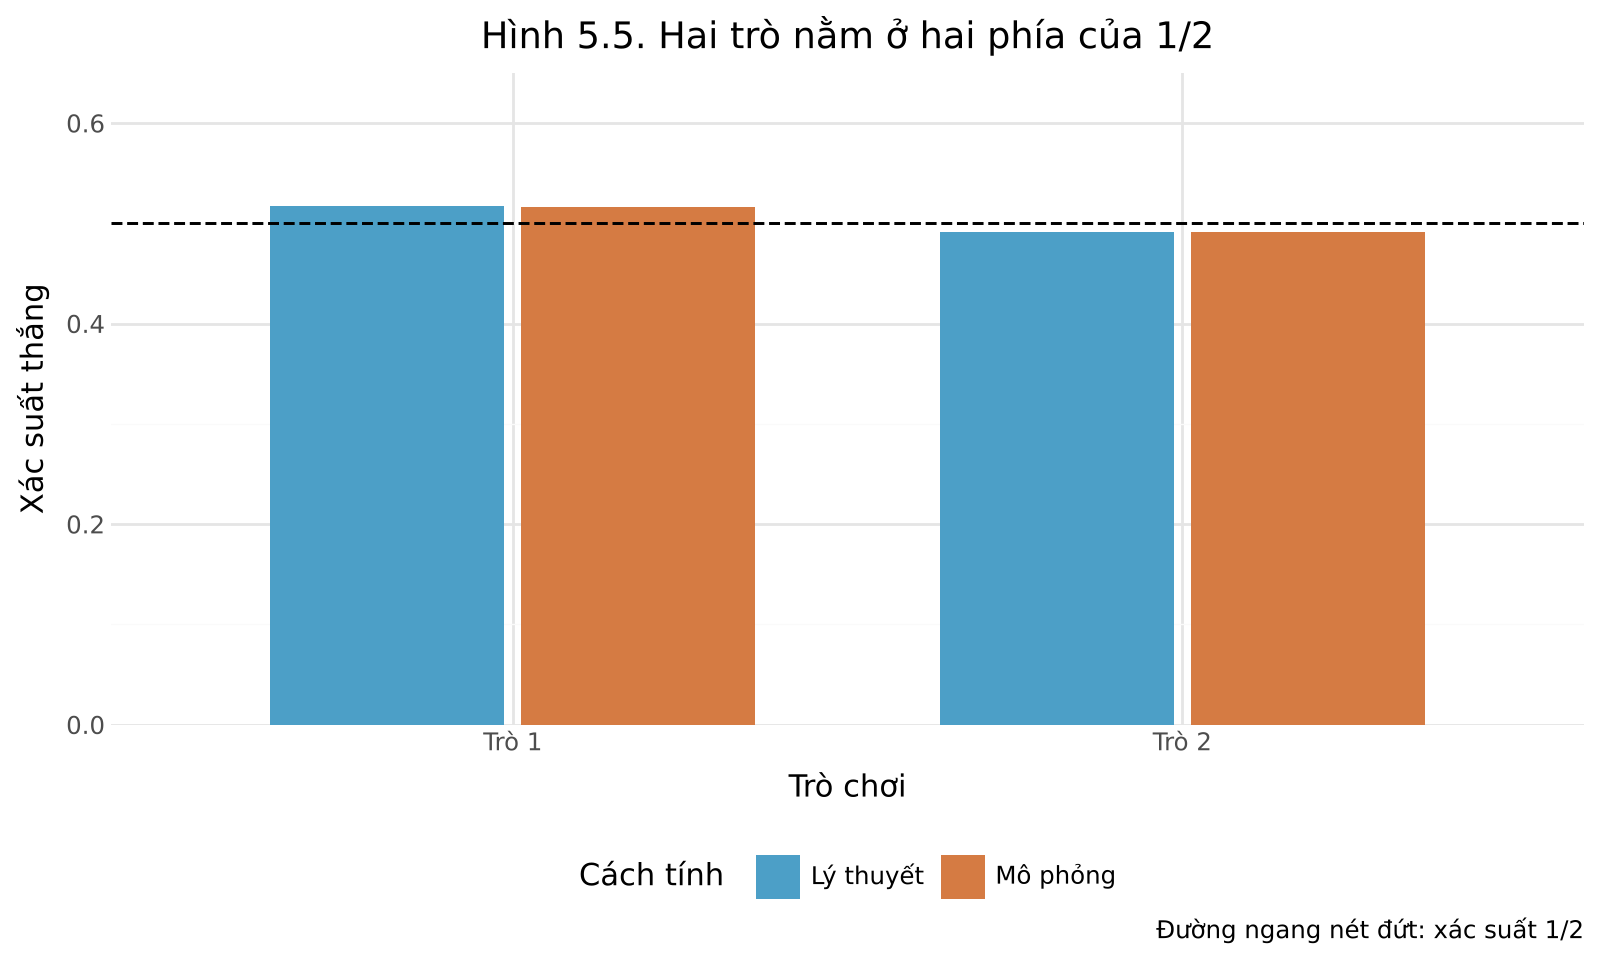

,Lý thuyết,Mô phỏng,Chênh lệch
Trò 1,0.517747,0.51644,-0.001307
Trò 2,0.491404,0.49092,-0.000484


In [12]:
exact_probs = np.array([1 - (5/6)**4, 1 - (35/36)**24])
sim_probs = np.array([win1.mean(), win2.mean()])
game_plot_data = pd.DataFrame({"Trò chơi": ["Trò 1", "Trò 2"],
                               "Lý thuyết": exact_probs, "Mô phỏng": sim_probs}).melt(
    id_vars="Trò chơi", var_name="Cách tính", value_name="Xác suất thắng")
comparison_plot = (
    p9.ggplot(game_plot_data, p9.aes("Trò chơi", "Xác suất thắng", fill="Cách tính"))
    + p9.geom_col(position=p9.position_dodge(width=0.75), width=0.70)
    + p9.geom_hline(yintercept=0.5, color="black", linetype="dashed", size=0.6)
    + p9.scale_fill_manual(values={"Lý thuyết": "#4C9FC7", "Mô phỏng": "#D57B43"})
    + p9.scale_y_continuous(limits=(0, 0.65), expand=(0, 0))
    + p9.labs(title="Hình 5.5. Hai trò nằm ở hai phía của 1/2", x="Trò chơi",
               y="Xác suất thắng", caption="Đường ngang nét đứt: xác suất 1/2")
    + p9.theme(figure_size=(8, 4.8), legend_position="bottom")
)
display(comparison_plot)
display(pd.DataFrame({"Lý thuyết": exact_probs, "Mô phỏng": sim_probs,
                      "Chênh lệch": sim_probs-exact_probs}, index=["Trò 1", "Trò 2"]))


Chênh lệch giữa mô phỏng và lý thuyết là dao động do số ván hữu hạn.

### Hình 5.6. Tần suất thắng tích lũy

Tại mỗi số ván $m$, lấy số ván thắng từ ván 1 đến ván $m$ chia cho $m$. `np.cumsum(wins)` cộng dồn số ván thắng; chia cho `np.arange(1, n_games+1)`, tức $1,2,\ldots,n$, được tỉ lệ thắng tính đến từng ván. Trục hoành dùng thang log để thấy rõ cả đoạn đầu lẫn đoạn cuối. Đường ngang là xác suất lý thuyết.

**Bạn đoán trước:** đoạn nào của đường dao động mạnh nhất?

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='x', y='y', color='Trò chơi'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_text` đặt chữ từ biến `label` tại tọa độ của từng hàng. `geom_hline` thêm đường ngang tại `yintercept`. `geom_line` nối các điểm theo thứ tự của `x`; đọc `group` hoặc ánh xạ màu để biết các đường được tách thế nào. Thử đổi một thuộc tính hiển thị đang có trong lớp vẽ hoặc `theme`, rồi chạy lại ô; giữ dữ liệu để so sánh hình trước và sau.

<!-- branch-plot-instructions:end -->

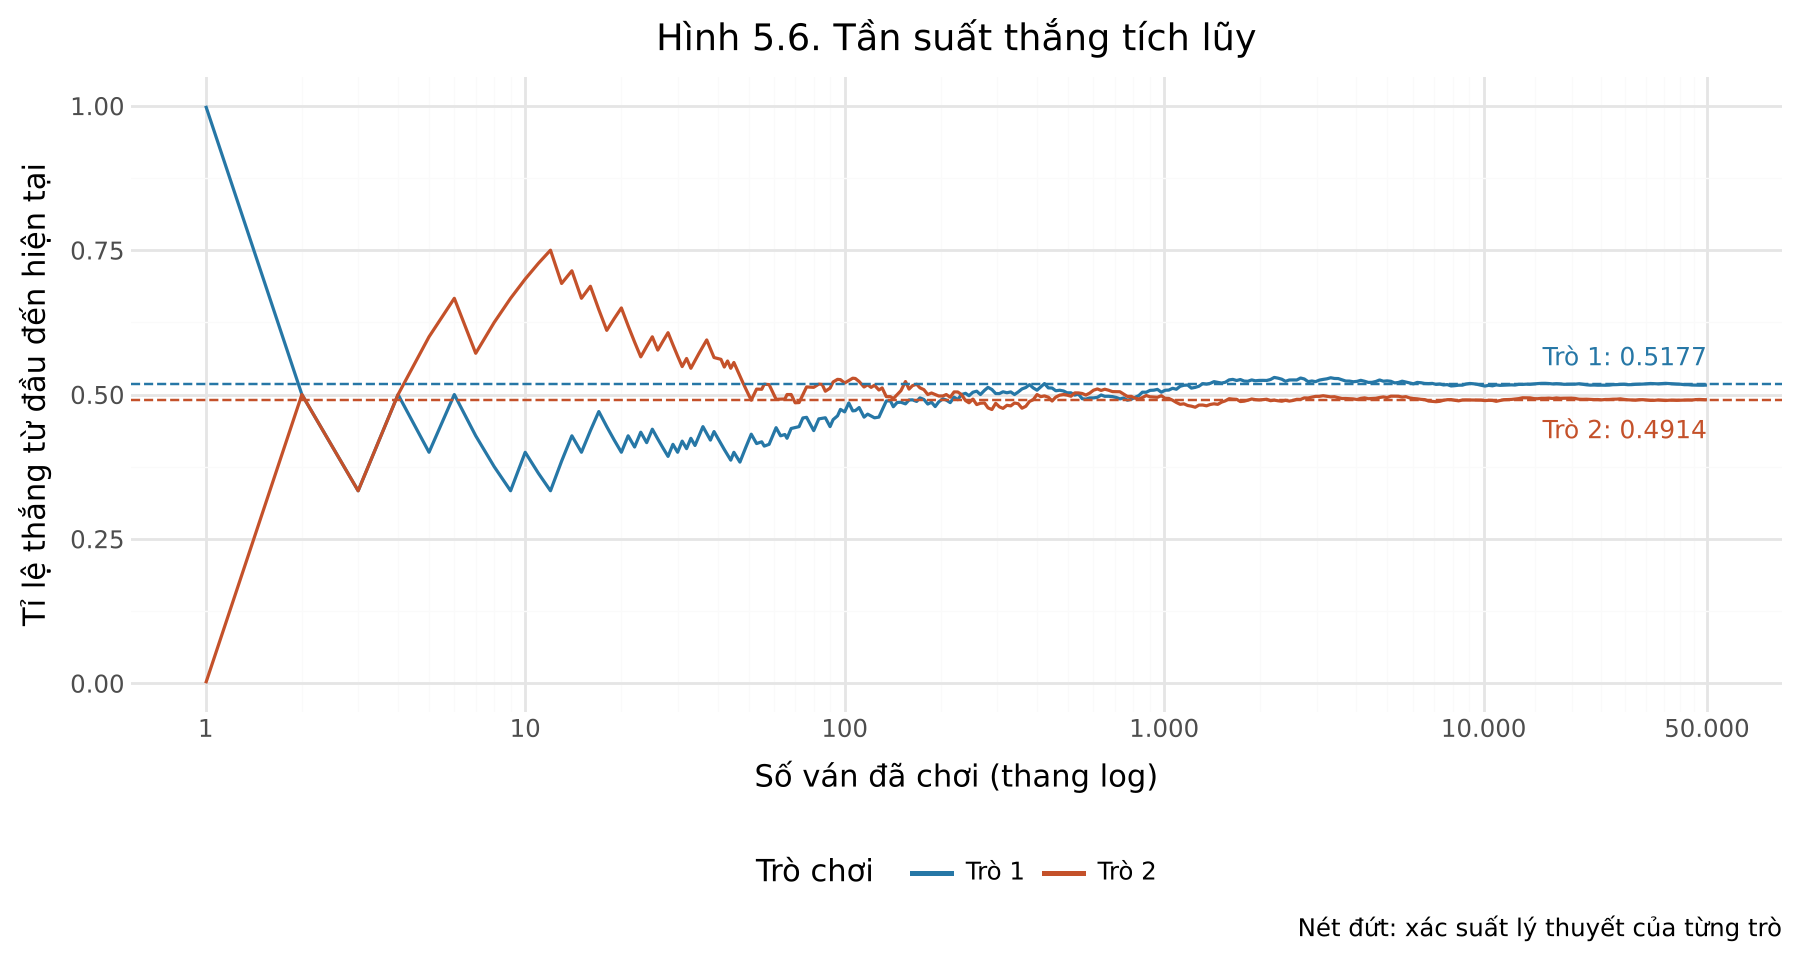

In [13]:
checkpoints = np.unique(np.geomspace(1, n_games, 400).astype(int))
rate_tables = []
for wins, theoretical, name in zip([win1, win2], exact_probs, ["Trò 1", "Trò 2"]):
    running_rate = np.cumsum(wins) / np.arange(1, n_games+1)
    rate_tables.append(pd.DataFrame({"Số ván": checkpoints,
                                      "Tỉ lệ thắng": running_rate[checkpoints-1], "Trò chơi": name}))
rate_data = pd.concat(rate_tables, ignore_index=True)
reference_data = pd.DataFrame({"Trò chơi": ["Trò 1", "Trò 2"], "Xác suất lý thuyết": exact_probs,
                               "x": [n_games, n_games], "y": exact_probs + np.array([0.05, -0.05]),
                               "label": [f"Trò 1: {exact_probs[0]:.4f}", f"Trò 2: {exact_probs[1]:.4f}"]})
log_breaks = [b for b in [1, 10, 100, 1000, 10000, 50000, 100000] if b <= n_games]
running_plot = (
    p9.ggplot(rate_data, p9.aes("Số ván", "Tỉ lệ thắng", color="Trò chơi"))
    + p9.geom_line(size=0.65)
    + p9.geom_hline(reference_data, p9.aes(yintercept="Xác suất lý thuyết", color="Trò chơi"),
                    inherit_aes=False, linetype="dashed", show_legend=False)
    + p9.geom_text(reference_data, p9.aes("x", "y", label="label", color="Trò chơi"),
                    inherit_aes=False, ha="right", size=9, show_legend=False)
    + p9.scale_x_log10(breaks=log_breaks, labels=[f"{b:,}".replace(",", ".") for b in log_breaks])
    + p9.scale_y_continuous(limits=(0, 1))
    + p9.scale_color_manual(values={"Trò 1": "#2677A6", "Trò 2": "#C4512A"})
    + p9.labs(title="Hình 5.6. Tần suất thắng tích lũy", x="Số ván đã chơi (thang log)",
               y="Tỉ lệ thắng từ đầu đến hiện tại", caption="Nét đứt: xác suất lý thuyết của từng trò")
    + p9.theme(figure_size=(9, 4.8), legend_position="bottom")
)
display(running_plot)


Đoạn đầu có rất ít ván, nên một ván thắng hay thua làm tỉ lệ đổi nhiều. Khi số ván tăng, dao động thường nhỏ dần và hai đường tiến gần xác suất lý thuyết. Không có bảo đảm điểm sau luôn gần hơn điểm trước.

*Thử thay đổi.* Đặt `n_games = 1000` hoặc `100000` ở ô thiết lập, rồi chạy lại toàn bộ notebook. Số ván lớn cần thêm thời gian và bộ nhớ.

### W05-CH01 — Mức độ 3: Ít nhất một mô-đun lỗi

Hệ thống có n mô-đun độc lập, mỗi mô-đun lỗi trong ngày với xác suất p. (1) Lập công thức ít nhất một lỗi; (2) với p=0,02, tìm n nguyên nhỏ nhất để xác suất vượt 0,5; (3) vì sao không dùng np làm xác suất chính xác?

<details><summary>Đáp án và lập luận — W05-CH01</summary>

*Câu 1.* Phần bù của "ít nhất một lỗi" là "không mô-đun nào lỗi". Mỗi mô-đun không lỗi với xác suất $1-p$; các mô-đun độc lập nên
$$P(\text{không lỗi nào})=(1-p)^n,\qquad P(\text{ít nhất một lỗi})=1-(1-p)^n.$$

*Câu 2.* Cần $1-0{,}98^n>0{,}5$, tức $0{,}98^n<0{,}5$.

- Lấy logarit hai vế: $n\ln 0{,}98<\ln 0{,}5$.
- Vì $\ln 0{,}98<0$, chia hai vế cho nó thì bất đẳng thức đổi chiều: $n>\dfrac{\ln 0{,}5}{\ln 0{,}98}\approx34{,}31$.
- Vậy $n=35$. Kiểm tra: $1-0{,}98^{34}\approx0{,}4969$ và $1-0{,}98^{35}\approx0{,}5069$.

*Câu 3.* $np=p+p+\cdots+p$ là tổng xác suất của $n$ biến cố "mô-đun $i$ lỗi". Các biến cố này không xung khắc (nhiều mô-đun có thể cùng lỗi), nên tổng đếm lặp những ngày có nhiều lỗi. Nó chỉ là chặn trên và có thể vượt 1.

</details>

Ô code dưới tìm $n$ bằng máy và vẽ hai đường: xác suất chính xác $1-(1-p)^n$ và tổng $np$.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='Số mô-đun n', y='Giá trị', color='Cách tính'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_hline` thêm đường ngang tại `yintercept`. `geom_line` nối các điểm theo thứ tự của `x`; đọc `group` hoặc ánh xạ màu để biết các đường được tách thế nào. Thử đổi một thuộc tính hiển thị đang có trong lớp vẽ hoặc `theme`, rồi chạy lại ô; giữ dữ liệu để so sánh hình trước và sau.

<!-- branch-plot-instructions:end -->

Số mô-đun nhỏ nhất: 35
n=34: 0.49686263202236935 ; n=35: 0.506925379381922


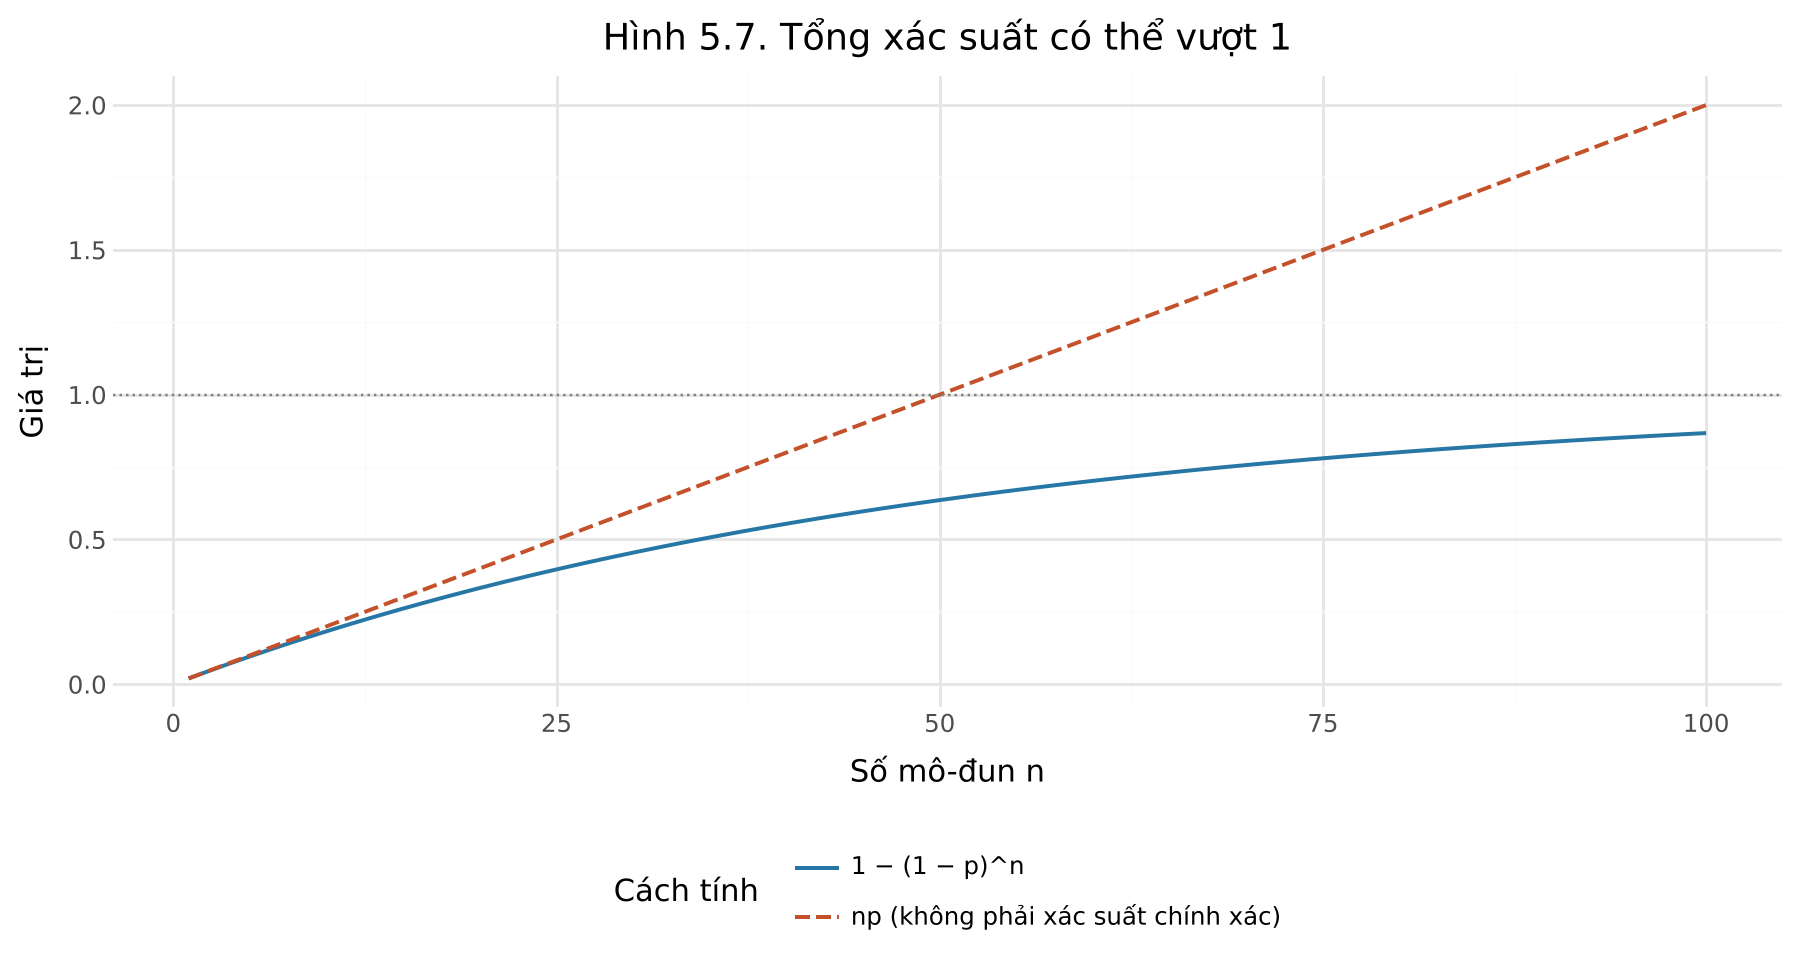

In [14]:
module_count = np.arange(1, 101)
failure_p = 0.02
at_least_one_failure = 1 - (1-failure_p)**module_count
first_over_half = module_count[at_least_one_failure > 0.5][0]
print("Số mô-đun nhỏ nhất:", first_over_half)
print("n=34:", 1-0.98**34, "; n=35:", 1-0.98**35)
failure_data = pd.DataFrame({"Số mô-đun n": module_count,
                             "1 − (1 − p)^n": at_least_one_failure,
                             "np (không phải xác suất chính xác)": module_count*failure_p}).melt(
    id_vars="Số mô-đun n", var_name="Cách tính", value_name="Giá trị")
failure_plot = (
    p9.ggplot(failure_data, p9.aes("Số mô-đun n", "Giá trị", color="Cách tính", linetype="Cách tính"))
    + p9.geom_line(size=0.8)
    + p9.geom_hline(yintercept=1, color="gray", linetype="dotted")
    + p9.scale_color_manual(values=["#2677A6", "#C4512A"])
    + p9.scale_linetype_manual(values=["solid", "dashed"])
    + p9.labs(title="Hình 5.7. Tổng xác suất có thể vượt 1", x="Số mô-đun n", y="Giá trị")
    + p9.guides(color=p9.guide_legend(nrow=2), linetype=p9.guide_legend(nrow=2))
    + p9.theme(figure_size=(9, 4.8), legend_position="bottom")
)
display(failure_plot)


Xác suất chính xác luôn nằm trong $[0,1]$. Đường $np$ vượt 1 khi $n>50$. Khi $p$ và $np$ đều nhỏ, $np$ gần với xác suất chính xác, nhưng gần không có nghĩa là bằng.

## 6. Xác suất toàn phần và định lý Bayes

### Xác suất toàn phần

Một nhà máy có hai dây chuyền. Dây chuyền A làm ra 60% sản phẩm, tỉ lệ lỗi 2%. Dây chuyền B làm ra 40% sản phẩm, tỉ lệ lỗi 5%. Chọn ngẫu nhiên một sản phẩm. Xác suất nó bị lỗi là bao nhiêu?

**Bạn đoán trước:** đáp án có phải trung bình cộng $\frac{2\%+5\%}{2}=3{,}5\%$ không?

Một sản phẩm lỗi đi qua đúng một trong hai đường: "từ A và lỗi" hoặc "từ B và lỗi". Tính từng đường bằng quy tắc nhân, rồi cộng:

$$P(\text{lỗi})=0{,}6\cdot0{,}02+0{,}4\cdot0{,}05=0{,}012+0{,}020=0{,}032.$$

Đáp án là 3,2%, không phải 3,5%. Đây là **trung bình có trọng số** của hai tỉ lệ lỗi, với trọng số là tỉ trọng sản lượng.

Tổng quát, các biến cố $A_1,\ldots,A_k$ tạo thành một **phân hoạch** nếu chúng đôi một xung khắc và hợp lại bằng $\Omega$. Nói cách khác, mỗi kết quả thuộc đúng một nhóm: mỗi sản phẩm thuộc đúng một dây chuyền, mỗi thư thuộc đúng một tài khoản. **Công thức xác suất toàn phần** là

$$P(B)=\sum_{i=1}^{k}P(B\mid A_i)\,P(A_i).$$

Đọc là: xác suất của $B$ bằng tổng, qua từng nhóm, của xác suất nhóm nhân với xác suất $B$ trong nhóm đó. $P(A_i)$ là trọng số của nhóm $i$. Nhóm có xác suất 0 có thể bỏ khỏi tổng.

<details><summary><b>Vì sao?</b> Chứng minh công thức xác suất toàn phần</summary>

*Bước 1.* Các $A_i$ phủ kín $\Omega$, nên $B=(B\cap A_1)\cup\cdots\cup(B\cap A_k)$.

*Bước 2.* Các $A_i$ rời nhau, nên các mảnh $B\cap A_i$ cũng rời nhau. Theo tiên đề 3: $P(B)=\sum_i P(B\cap A_i)$.

*Bước 3.* Theo quy tắc nhân: $P(B\cap A_i)=P(B\mid A_i)\,P(A_i)$. $\blacksquare$

</details>

### Định lý Bayes

Giờ đổi chiều câu hỏi: **biết** sản phẩm đã lỗi, xác suất nó đến từ dây chuyền B là bao nhiêu?

Theo định nghĩa xác suất có điều kiện, lấy đường "B và lỗi" chia cho tổng mọi đường dẫn tới lỗi:

$$P(\text{dây chuyền B}\mid\text{lỗi})=\frac{0{,}4\cdot0{,}05}{0{,}032}=\frac{0{,}020}{0{,}032}=0{,}625.$$

Tỉ trọng của B tăng từ 40% lên 62,5% khi chỉ xét các sản phẩm lỗi, vì B có tỉ lệ lỗi cao hơn. Đây là cập nhật theo thông tin mới, không phải khẳng định sản phẩm lỗi chắc chắn đến từ B.

Tổng quát, với phân hoạch $A_1,\ldots,A_k$ và $P(B)>0$, **định lý Bayes** là

$$P(A_j\mid B)=\frac{P(B\mid A_j)\,P(A_j)}{\sum_{i=1}^k P(B\mid A_i)\,P(A_i)}.$$

Đọc là: xác suất của nhóm $A_j$ khi biết $B$ bằng phần đóng góp của nhóm $A_j$ vào $B$, chia cho tổng đóng góp của mọi nhóm.

<details><summary><b>Vì sao?</b> Chứng minh định lý Bayes</summary>

*Bước 1.* Theo định nghĩa: $P(A_j\mid B)=P(A_j\cap B)/P(B)$.

*Bước 2.* Tử số theo quy tắc nhân: $P(A_j\cap B)=P(B\mid A_j)\,P(A_j)$.

*Bước 3.* Mẫu số theo công thức xác suất toàn phần. $\blacksquare$

Định lý Bayes không chứa ý tưởng mới. Nó chỉ là định nghĩa xác suất có điều kiện, viết theo chiều ngược lại.

</details>

### W05-EX04 — Mức độ 2: Truy nguồn sản phẩm lỗi

Dây chuyền A tạo 60% sản lượng với 2% lỗi; B tạo 40% với 5% lỗi. Chọn ngẫu nhiên một sản phẩm và biết nó lỗi. Xác suất sản phẩm đến từ B là bao nhiêu? So với 40% ban đầu.

<details><summary>Đáp án và lập luận — W05-EX04</summary>

Gọi $L$: sản phẩm lỗi; $A$, $B$: sản phẩm từ dây chuyền A, B.

*Bước 1: dữ kiện.* $P(A)=0{,}60$, $P(B)=0{,}40$, $P(L\mid A)=0{,}02$, $P(L\mid B)=0{,}05$.

*Bước 2: xác suất toàn phần.* $P(L)=0{,}02\cdot0{,}60+0{,}05\cdot0{,}40=0{,}012+0{,}020=0{,}032$.

*Bước 3: Bayes.* $P(B\mid L)=\dfrac{P(L\mid B)\,P(B)}{P(L)}=\dfrac{0{,}020}{0{,}032}=0{,}625$.

*Bước 4: so sánh.* B tạo 40% sản phẩm nhưng chiếm 62,5% sản phẩm lỗi, vì tỉ lệ lỗi của B cao hơn. Lưu ý $P(L\mid B)=0{,}05$ và $P(B\mid L)=0{,}625$ là hai đại lượng khác nhau, không thay thế cho nhau được.

</details>

### W05-BT07: Tỉ lệ thư rác chung

Ba tài khoản nhận 70%, 20%, 10% toàn bộ thư. Tỉ lệ thư rác từng tài khoản là 1%, 2%, 5%. Mỗi thư thuộc đúng một tài khoản. Chọn đều một thư từ toàn bộ thư: tính xác suất thư rác và nêu phân hoạch.

<details><summary>Đáp án và lập luận — W05-BT07</summary>

*Bước 1: phân hoạch.* $A_i$: thư thuộc tài khoản $i$, $i=1,2,3$. Mỗi thư thuộc đúng một tài khoản, nên $A_1,A_2,A_3$ là một phân hoạch.

*Bước 2: xác suất toàn phần.*
$$P(\text{rác})=0{,}7\cdot0{,}01+0{,}2\cdot0{,}02+0{,}1\cdot0{,}05=0{,}007+0{,}004+0{,}005=0{,}016.$$

Vậy 1,6% thư là thư rác. Trung bình cộng đơn giản $\frac{1\%+2\%+5\%}{3}\approx2{,}67\%$ là sai, vì ba tài khoản nhận số thư rất khác nhau.

</details>

### W05-BT08: Thư rác thuộc tài khoản nào?

Dùng ba tài khoản và tỉ lệ ở W05-BT07. Biết thư chọn là rác, (1) tính xác suất thuộc từng tài khoản; (2) so với tỉ trọng ban đầu; (3) tài khoản có tỉ lệ rác cao nhất có nhất thiết là nguồn có khả năng cao nhất không?

<details><summary>Đáp án và lập luận — W05-BT08</summary>

*Bước 1.* Từ W05-BT07: $P(\text{rác})=0{,}016$, gồm ba phần $0{,}007$, $0{,}004$, $0{,}005$ của ba tài khoản.

*Bước 2: Bayes.* Chia từng phần cho tổng:

| Tài khoản | Ban đầu $P(A_i)$ | $P(A_i\cap\text{rác})$ | Sau khi biết thư rác $P(A_i\mid\text{rác})$ |
|---|---|---|---|
| 1 | 0,70 | 0,007 | $0{,}007/0{,}016=0{,}4375$ |
| 2 | 0,20 | 0,004 | $0{,}004/0{,}016=0{,}2500$ |
| 3 | 0,10 | 0,005 | $0{,}005/0{,}016=0{,}3125$ |

*Bước 3: so sánh.* Tài khoản 1 giảm tỉ trọng, từ 0,70 xuống 0,4375; tài khoản 2 và 3 tăng. Ba xác suất sau cập nhật cộng lại bằng 1.

*Câu 3.* Không. Tài khoản 3 có tỉ lệ rác cao nhất, nhưng tài khoản 1 vẫn là nguồn khả dĩ nhất vì nhận nhiều thư hơn hẳn.

</details>

**Code.** Ô dưới làm đúng các bước của W05-BT08 rồi vẽ hình so sánh.

- `prior`: tỉ trọng thư của ba tài khoản, $P(A_i)$.
- `spam_rate`: tỉ lệ thư rác trong từng tài khoản, $P(\text{rác}\mid A_i)$.
- `joint = prior * spam_rate`: quy tắc nhân, ra $P(A_i\cap\text{rác})$.
- `joint / joint.sum()`: chia cho tổng (xác suất toàn phần), ra $P(A_i\mid\text{rác})$.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='Tài khoản', y='Xác suất', fill='Tập tham chiếu'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_col` vẽ cột có độ dài lấy trực tiếp từ giá trị `y` đã tính trong bảng. Thử đổi một thuộc tính hiển thị đang có trong lớp vẽ hoặc `theme`, rồi chạy lại ô; giữ dữ liệu để so sánh hình trước và sau.

<!-- branch-plot-instructions:end -->

,Tài khoản,Ban đầu,Thư rác trong nhóm,Nhóm và thư rác,Sau khi biết rác
0,1,0.7,0.01,0.007,0.4375
1,2,0.2,0.02,0.004,0.2500
2,3,0.1,0.05,0.005,0.3125


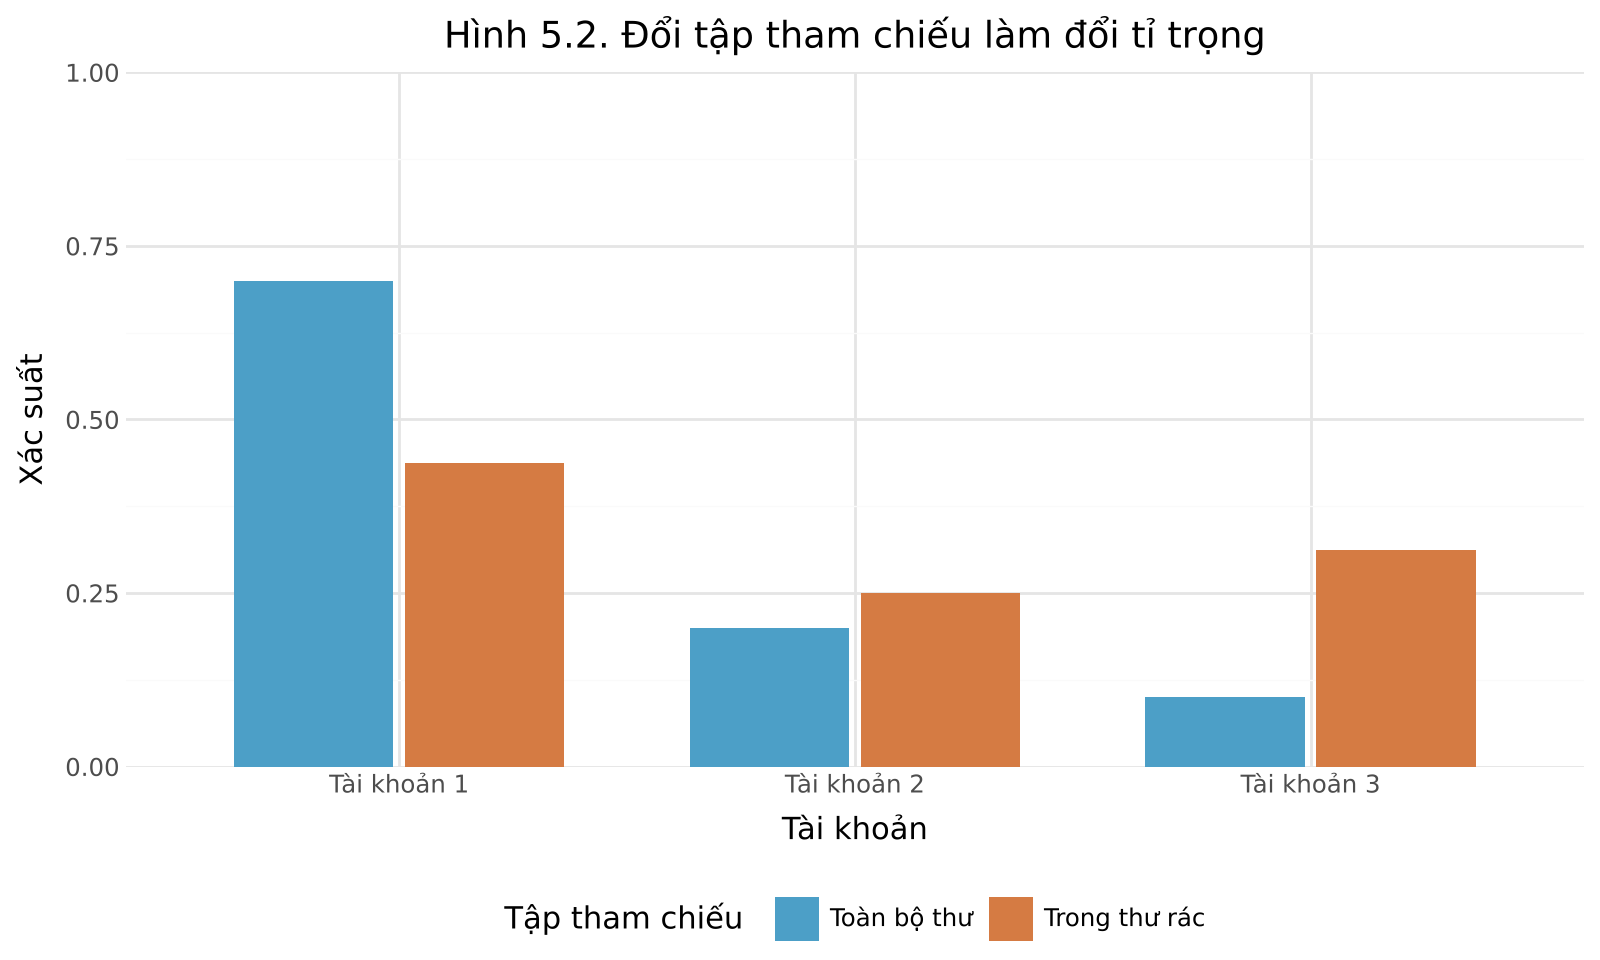

In [15]:
prior = np.array([0.70, 0.20, 0.10])
spam_rate = np.array([0.01, 0.02, 0.05])
joint = prior * spam_rate
posterior = joint / joint.sum()
display(pd.DataFrame({"Tài khoản": [1, 2, 3], "Ban đầu": prior,
                      "Thư rác trong nhóm": spam_rate,
                      "Nhóm và thư rác": joint, "Sau khi biết rác": posterior}))
# Dữ liệu dạng dài: mỗi hàng là một tài khoản trong một tập tham chiếu.
account_plot_data = pd.DataFrame({"Tài khoản": ["Tài khoản 1", "Tài khoản 2", "Tài khoản 3"],
                                  "Toàn bộ thư": prior, "Trong thư rác": posterior}).melt(
    id_vars="Tài khoản", var_name="Tập tham chiếu", value_name="Xác suất")
account_plot = (
    p9.ggplot(account_plot_data, p9.aes("Tài khoản", "Xác suất", fill="Tập tham chiếu"))
    + p9.geom_col(position=p9.position_dodge(width=0.75), width=0.70)
    + p9.scale_fill_manual(values={"Toàn bộ thư": "#4C9FC7", "Trong thư rác": "#D57B43"})
    + p9.scale_y_continuous(limits=(0, 1), expand=(0, 0))
    + p9.labs(title="Hình 5.2. Đổi tập tham chiếu làm đổi tỉ trọng", x="Tài khoản", y="Xác suất")
    + p9.theme(figure_size=(8, 4.8), legend_position="bottom")
)
display(account_plot)


Tài khoản 1 giảm tỉ trọng, tài khoản 2 và 3 tăng. Hai màu cột là hai phân phối với hai mẫu số khác nhau: toàn bộ thư, và chỉ thư rác.

Đọc hình theo Ngữ pháp đồ họa (Tuần 03): dữ liệu là bảng tỉ trọng; trục x ánh xạ tài khoản; trục y ánh xạ xác suất; màu ánh xạ tập tham chiếu; dạng hình học là cột. Cách đọc này dùng được với mọi thư viện vẽ.

### W05-EX05 — Mức độ 3: Mô hình SIR

Trong quần thể của bài toán, 60% cảm nhiễm S (chưa nhiễm nhưng có thể nhiễm), 10% đang nhiễm I, 30% hồi phục R. Xét nghiệm âm tính đúng ở 95% S; dương tính đúng ở 99% I; âm tính đúng ở 65% R. Biết kết quả dương tính, tính xác suất thực sự đang nhiễm.

<details><summary>Đáp án và lập luận — W05-EX05</summary>

**Cách 1: công thức.**

*Bước 1: xác suất dương tính trong từng nhóm.* Đề cho tỉ lệ âm tính đúng ở S và R, nên lấy phần bù: $P(+\mid S)=1-0{,}95=0{,}05$, $P(+\mid I)=0{,}99$, $P(+\mid R)=1-0{,}65=0{,}35$.

*Bước 2: xác suất toàn phần.*
$$P(+)=0{,}60\cdot0{,}05+0{,}10\cdot0{,}99+0{,}30\cdot0{,}35=0{,}030+0{,}099+0{,}105=0{,}234.$$

*Bước 3: Bayes.*
$$P(I\mid+)=\frac{0{,}099}{0{,}234}=\frac{11}{26}\approx0{,}4231.$$

**Cách 2: tần số tự nhiên.** Thay xác suất bằng số người trong một nhóm 10.000 người tưởng tượng.

| Nhóm | Số người | Dương tính | Âm tính |
|---|---|---|---|
| S (cảm nhiễm) | 6.000 | 300 | 5.700 |
| I (đang nhiễm) | 1.000 | **990** | 10 |
| R (hồi phục) | 3.000 | 1.050 | 1.950 |
| **Tổng** | 10.000 | **2.340** | 7.660 |

Trong 2.340 người dương tính, có 990 người đang nhiễm: $P(I\mid+)=\frac{990}{2340}=\frac{11}{26}$. Mỗi con số trong bảng có nghĩa cụ thể. Bảng cũng cho thấy vì sao kết quả nhỏ hơn 0,99 nhiều: nhóm S và R rất đông, nên dù tỉ lệ dương tính ở đó thấp hơn, số người dương tính vẫn lớn ($300+1050=1350$ người).

Xác suất đang nhiễm tăng từ 0,10 lên khoảng 0,42 sau khi biết dương tính. Các tham số là giả định của bài toán, không phải hiệu năng của một xét nghiệm thực tế.

</details>

### Hình 5.3. Sơ đồ cây của W05-EX05

Sơ đồ cây gói ba quy tắc vào một hình:

- **Nhân dọc theo nhánh** là quy tắc nhân. Nhánh thứ hai luôn là xác suất có điều kiện, khi đã đi qua nhánh thứ nhất.
- **Cộng các lá** cùng loại là xác suất toàn phần. Được cộng vì các đường đi rời nhau.
- **Bayes** là lấy một lá chia cho tổng các lá cùng loại.

Trên cây ở ô dưới, hãy chỉ ra đâu là $P(I)$, đâu là $P(+\mid I)$ và đâu là $P(I\cap+)$. Nhánh "+" của S và R có xác suất 0,05 và 0,35, vì đề cho tỉ lệ âm tính đúng.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='x', y='y'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_label` đặt nhãn từ biến `label` và vẽ nền quanh chữ. `geom_segment` nối cặp tọa độ đầu–cuối `x`, `y`, `xend`, `yend`. Thử đổi một thuộc tính hiển thị đang có trong lớp vẽ hoặc `theme`, rồi chạy lại ô; giữ dữ liệu để so sánh hình trước và sau.

<!-- branch-plot-instructions:end -->

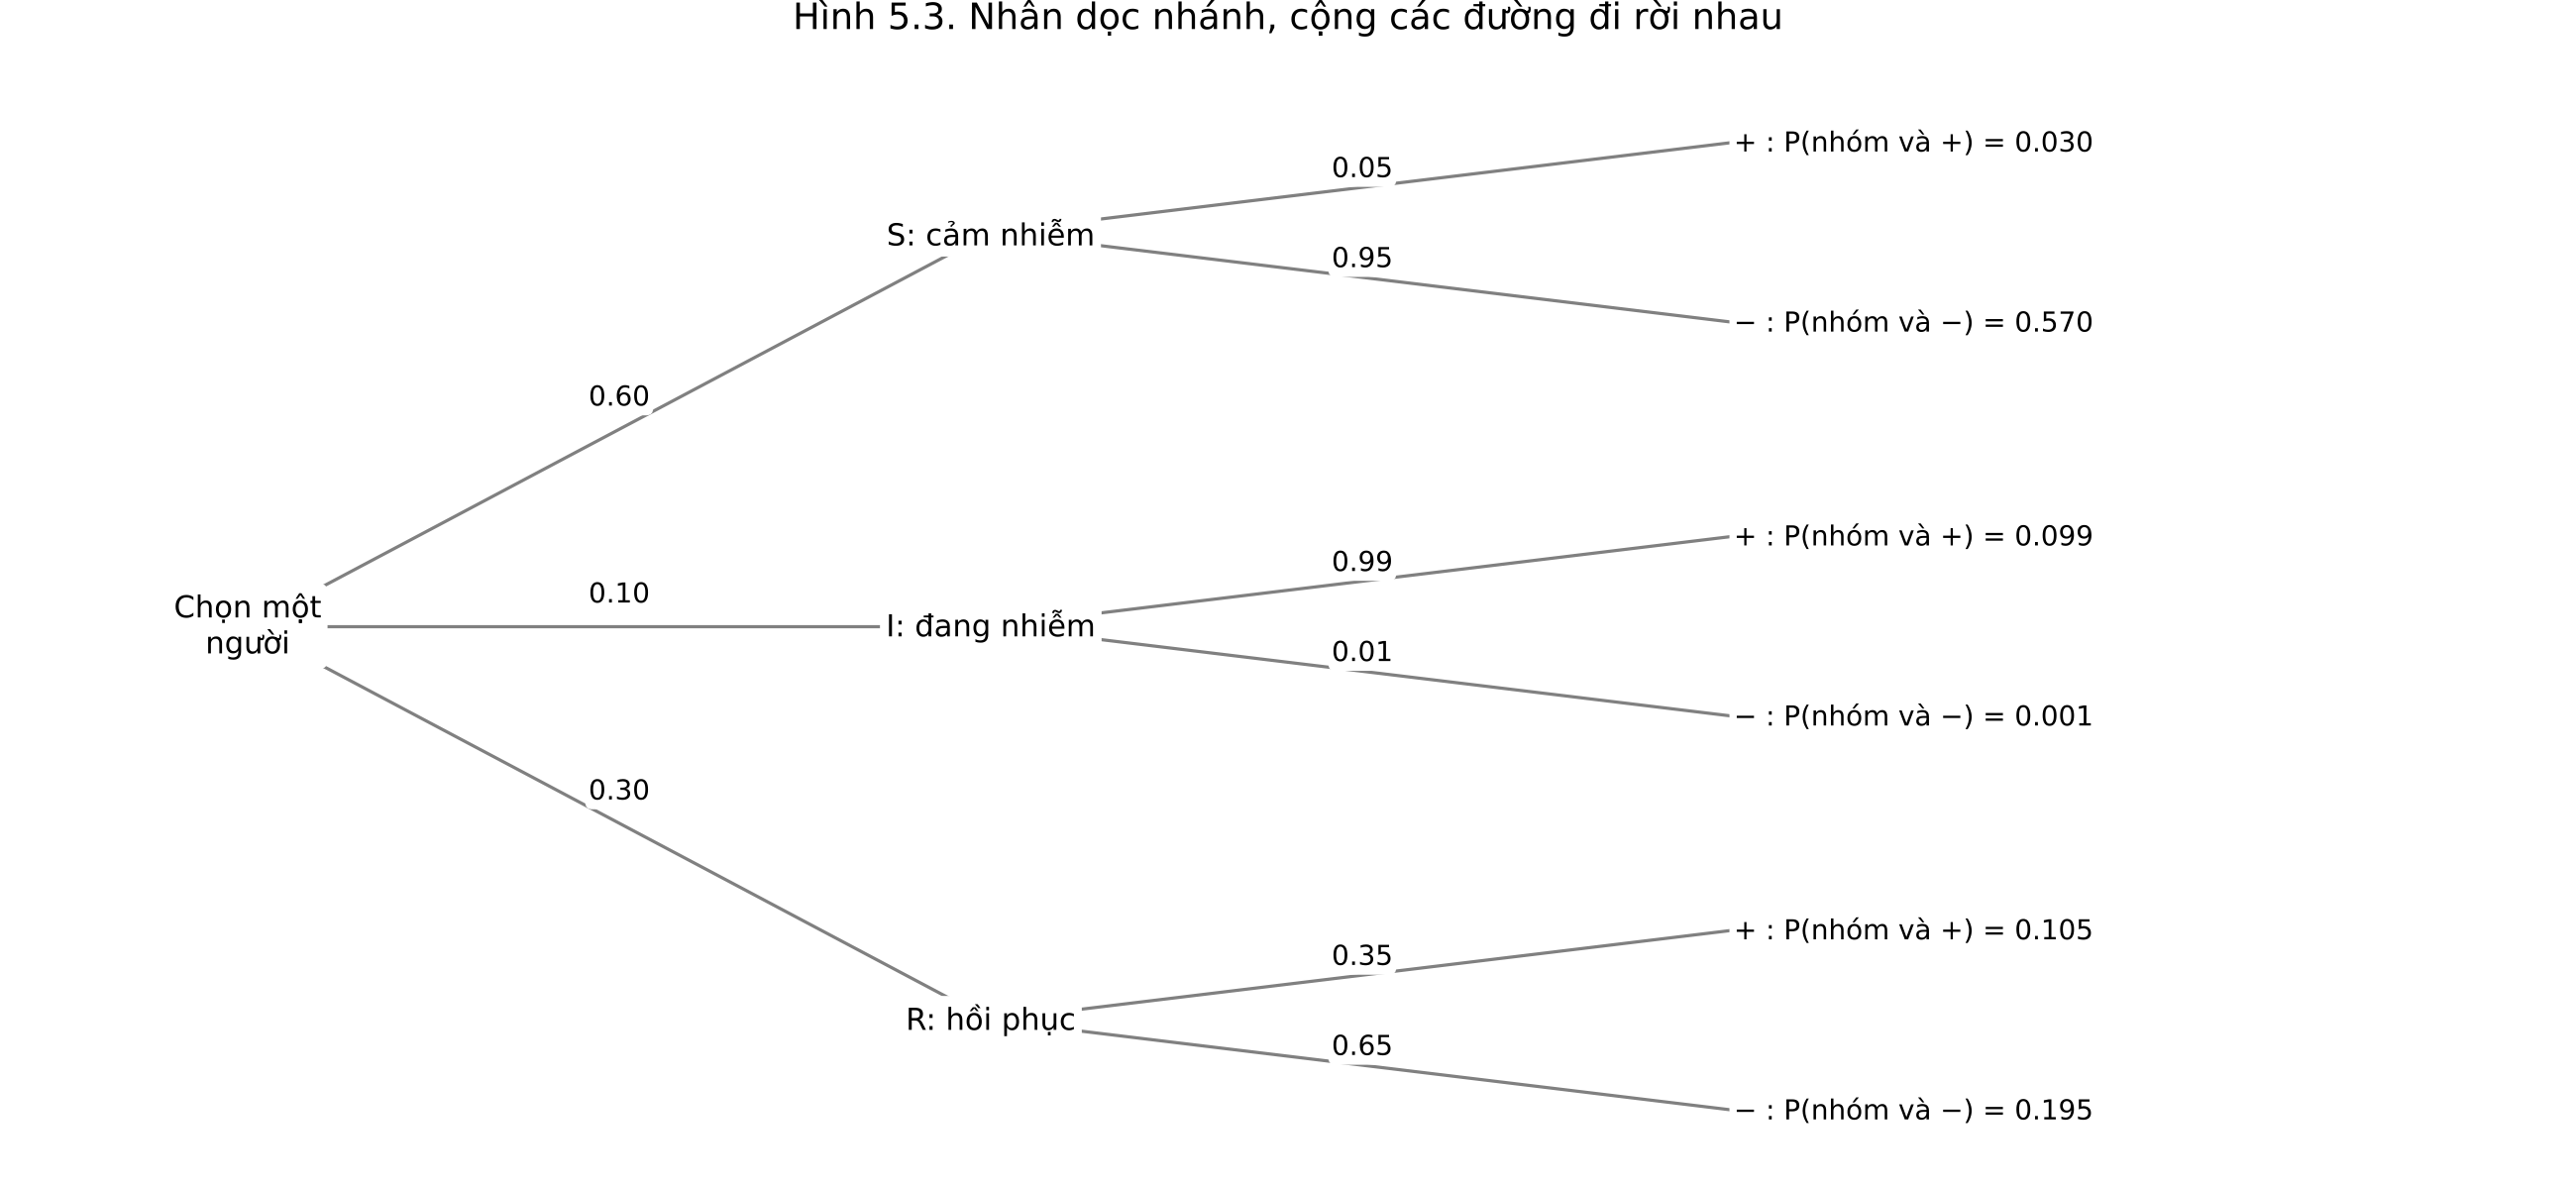

In [16]:
groups = ["S: cảm nhiễm", "I: đang nhiễm", "R: hồi phục"]
group_probs = np.array([0.60, 0.10, 0.30])
positive_probs = np.array([0.05, 0.99, 0.35])
# Ba bảng giữ riêng nhánh, xác suất trên nhánh và nhãn kết quả.
segments, branch_labels, group_nodes, leaf_nodes = [], [], [], []
for i, (name, p_group, p_plus) in enumerate(zip(groups, group_probs, positive_probs)):
    y = 0.85 - i * 0.35
    segments.append({"x": 0.0, "y": 0.5, "xend": 3.0, "yend": y})
    branch_labels.append({"x": 1.5, "y": (0.5+y)/2+0.03, "label": f"{p_group:.2f}"})
    group_nodes.append({"x": 3.0, "y": y, "label": name})
    for sign, p_test, delta in [("+", p_plus, 0.08), ("−", 1-p_plus, -0.08)]:
        segments.append({"x": 3.0, "y": y, "xend": 6.0, "yend": y+delta})
        branch_labels.append({"x": 4.5, "y": y+delta/2+0.018, "label": f"{p_test:.2f}"})
        leaf_nodes.append({"x": 6.0, "y": y+delta,
                           "label": f"{sign} : P(nhóm và {sign}) = {p_group*p_test:.3f}"})
root_node = pd.DataFrame({"x": [0.0], "y": [0.5], "label": ["Chọn một\nngười"]})
sir_tree = (
    p9.ggplot()
    + p9.geom_segment(pd.DataFrame(segments), p9.aes("x", "y", xend="xend", yend="yend"),
                      color="gray", size=0.65)
    + p9.geom_label(pd.DataFrame(branch_labels), p9.aes("x", "y", label="label"),
                    size=10, label_size=0, label_padding=0.12)
    + p9.geom_label(pd.DataFrame(group_nodes), p9.aes("x", "y", label="label"),
                    size=11, label_size=0, label_padding=0.2)
    + p9.geom_label(root_node, p9.aes("x", "y", label="label"), size=11,
                    label_size=0, label_padding=0.2)
    + p9.geom_label(pd.DataFrame(leaf_nodes), p9.aes("x", "y", label="label"),
                    ha="left", size=10, label_size=0, label_padding=0.16)
    + p9.coord_cartesian(xlim=(-1.0, 9.4), ylim=(0, 1), expand=False)
    + p9.labs(title="Hình 5.3. Nhân dọc nhánh, cộng các đường đi rời nhau")
    + p9.theme_void()
    + p9.theme(figure_size=(13, 6))
)
display(sir_tree)


Chỉ ba lá dương tính góp vào mẫu số 0,234. Lá "I và +" góp 0,099 vào tử số. Trả lời 0,99 là nhầm $P(+\mid I)$ với $P(I\mid+)$.

### Hình 5.4. Khi nhóm đang nhiễm hiếm hơn

Hình tương tác dưới cho đổi tỉ lệ nhóm đang nhiễm $P(I)$. Phần còn lại vẫn chia cho S và R theo tỉ lệ 2:1; các tỉ lệ xét nghiệm giữ như đề bài. Thanh trượt chỉ đổi **mô hình giả định**, không phải dữ liệu thực tế.

Trong code, `weights` là xác suất của ba nhóm ứng với mỗi giá trị $P(I)$; `weights * positive_probs` là ba lá dương tính; chia cho tổng được $P(\text{nhóm}\mid+)$. Ô này dùng `groups` và `positive_probs` của ô vẽ cây.

**Bạn đoán trước:** $P(I)$ càng nhỏ thì một kết quả dương tính còn đáng tin đến mức nào?

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** `geom_text` đặt chữ từ biến `label` tại tọa độ của từng hàng. `geom_col` vẽ cột có độ dài lấy trực tiếp từ giá trị `y` đã tính trong bảng. Chạy ô để hiện hình ban đầu; widget cần kernel đang chạy. Đổi tham số của hàm vẽ và chạy lại nếu giao diện không hỗ trợ widget.

<!-- branch-plot-instructions:end -->

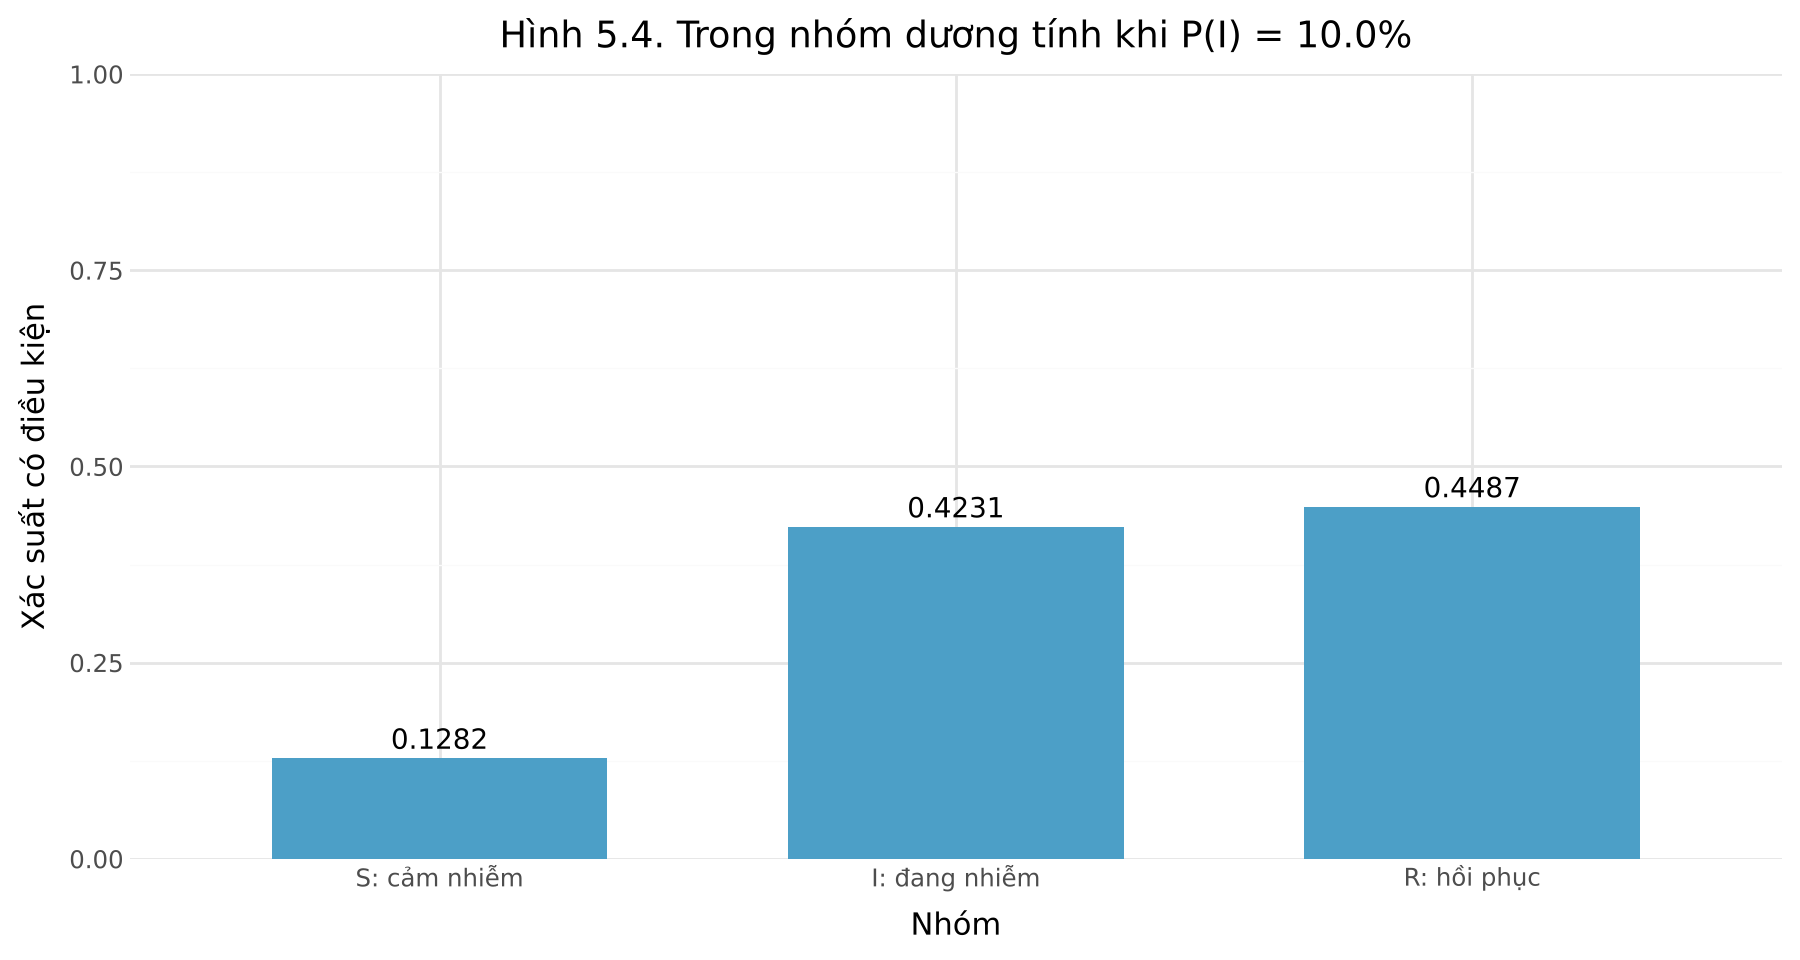

SelectionSlider(continuous_update=False, description='Tỉ lệ I:', index=3, layout=Layout(width='650px'), option…

In [17]:
prevalences = [0.001, 0.01, 0.05, 0.10, 0.30, 0.60]

def prevalence_plot(prevalence):
    weights = np.array([(1-prevalence)*2/3, prevalence, (1-prevalence)/3])
    positive_joint = weights * positive_probs
    result = positive_joint / positive_joint.sum()
    plot_data = pd.DataFrame({"Nhóm": pd.Categorical(groups, categories=groups, ordered=True),
                              "Xác suất có điều kiện": result})
    return (
        p9.ggplot(plot_data, p9.aes("Nhóm", "Xác suất có điều kiện"))
        + p9.geom_col(fill="#4C9FC7", width=0.65)
        + p9.geom_text(p9.aes(label="Xác suất có điều kiện"), format_string="{:.4f}",
                        nudge_y=0.025, size=10)
        + p9.scale_y_continuous(limits=(0, 1), expand=(0, 0))
        + p9.labs(title=f"Hình 5.4. Trong nhóm dương tính khi P(I) = {prevalence:.1%}",
                   x="Nhóm", y="Xác suất có điều kiện")
        + p9.theme(figure_size=(9, 4.8))
    )

# PNG ban đầu nằm ngay trong output để vẫn đọc được khi mở bản tĩnh.
prevalence = 0.10  # Có thể sửa giá trị này rồi chạy lại ô nếu không hiện widget.
bayes_display = display(prevalence_plot(prevalence), display_id=True)
try:
    import ipywidgets as widgets
    prevalence_slider = widgets.SelectionSlider(
        options=[(f"{p:.1%}", p) for p in prevalences], value=prevalence,
        description="Tỉ lệ I:", continuous_update=False,
        layout=widgets.Layout(width="650px"))

    def update_prevalence(change):
        bayes_display.update(prevalence_plot(change["new"]))

    prevalence_slider.observe(update_prevalence, names="value")
    display(prevalence_slider)
except ImportError:
    print("Để dùng thanh trượt cần ipywidgets; hiện có thể sửa prevalence rồi chạy lại ô.")


Khi nhóm I hiếm, phần lớn kết quả dương tính đến từ các nhóm khác, dù $P(+\mid I)=0{,}99$. Xác suất sau cập nhật phụ thuộc cả tỉ lệ ban đầu lẫn xác suất của bằng chứng trong từng nhóm.

*Thử thay đổi.* Thanh trượt chỉ đổi Hình 5.4. Muốn đổi cây ở Hình 5.3, sửa `group_probs` và `positive_probs` trong ô vẽ cây rồi chạy lại từ ô đó; giữ tổng các xác suất nhóm bằng 1. Chạy lại từ ô thiết lập để trở về mô hình ban đầu.

## 7. Bài tập tổng hợp

Các bài dưới phối hợp mọi quy tắc của buổi. Trước khi tính, hãy viết ra: phép thử, các biến cố, thông tin đã biết (điều kiện) và cơ chế chọn.

### W05-CASE01 — Mức độ 3: Hai thiết bị báo cháy

Khi đã có cháy, D1 báo đúng với xác suất 0,95 và D2 với 0,92; chúng hoạt động độc lập trong điều kiện này. Hệ chữa cháy hoạt động khi ít nhất một thiết bị báo đúng. Tính (a) cả hai báo đúng; (b) hệ hoạt động; (c) hệ không hoạt động.

<details><summary>Đáp án và lập luận — W05-CASE01</summary>

Mọi xác suất dưới đây đều tính **trong điều kiện đã có cháy**. Gọi $D_1$, $D_2$: thiết bị 1, 2 báo đúng. $P(D_1)=0{,}95$, $P(D_2)=0{,}92$, hai biến cố độc lập.

*(a) Cả hai báo đúng.* Độc lập nên nhân: $P(D_1\cap D_2)=0{,}95\cdot0{,}92=0{,}874$.

*(b) Hệ hoạt động* khi ít nhất một thiết bị báo đúng. Quy tắc cộng:
$$P(D_1\cup D_2)=0{,}95+0{,}92-0{,}874=0{,}996.$$

*(c) Hệ không hoạt động* là phần bù của (b): $1-0{,}996=0{,}004$.

*Cách khác cho (c).* Hệ không hoạt động khi cả hai đều không báo, tức $\overline{D_1}\cap\overline{D_2}$. Vì $D_1$, $D_2$ độc lập nên các phần bù cũng độc lập (mục 4), do đó xác suất này là $0{,}05\cdot0{,}08=0{,}004$.

Không dùng các số này cho tình huống chưa biết có cháy hay không.

</details>

### W05-TH01: Chuyển bi giữa hai hộp

Hộp 1 có 2 trắng, 1 đen; hộp 2 có 1 trắng, 5 đen. Chọn đều một viên từ hộp 1, chuyển sang hộp 2, trộn đều rồi chọn đều một viên hộp 2. (1) Vẽ cây; (2) tính xác suất lần lấy hộp 2 được trắng; (3) biết lần đó trắng, tính xác suất viên đã chuyển cũng trắng.

<details><summary>Đáp án và lập luận — W05-TH01</summary>

Gọi $A$: viên chuyển sang là trắng; $B$: viên rút từ hộp 2 là trắng.

*Câu 1: sơ đồ cây.* Bước 1 (chuyển): $P(A)=\frac23$, $P(\overline{A})=\frac13$. Bước 2 (rút từ hộp 2, lúc này có 7 viên):

| Nhánh | Hộp 2 sau khi chuyển | $P(B\mid\text{nhánh})$ | $P(\overline{B}\mid\text{nhánh})$ |
|---|---|---|---|
| $A$ | 2 trắng, 5 đen | $2/7$ | $5/7$ |
| $\overline{A}$ | 1 trắng, 6 đen | $1/7$ | $6/7$ |

*Câu 2: xác suất toàn phần.* Nhân dọc từng nhánh, cộng hai đường đi tới $B$:
$$P(B)=\frac23\cdot\frac27+\frac13\cdot\frac17=\frac4{21}+\frac1{21}=\frac5{21}.$$

*Câu 3: Bayes.*
$$P(A\mid B)=\frac{4/21}{5/21}=\frac45.$$

Biết viên rút ra là trắng, xác suất viên đã chuyển là trắng tăng từ $\frac23$ lên $\frac45$.

</details>

Ô dưới vẽ cây hai bước của W05-TH01. Đường "chuyển trắng rồi rút trắng" có xác suất $\frac4{21}\approx0{,}1905$; đường "chuyển đen rồi rút trắng" có xác suất $\frac1{21}\approx0{,}0476$. Tổng $\frac5{21}$ là mẫu số của câu 3.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='x', y='y'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_label` đặt nhãn từ biến `label` và vẽ nền quanh chữ. `geom_segment` nối cặp tọa độ đầu–cuối `x`, `y`, `xend`, `yend`. Thử đổi một thuộc tính hiển thị đang có trong lớp vẽ hoặc `theme`, rồi chạy lại ô; giữ dữ liệu để so sánh hình trước và sau.

<!-- branch-plot-instructions:end -->

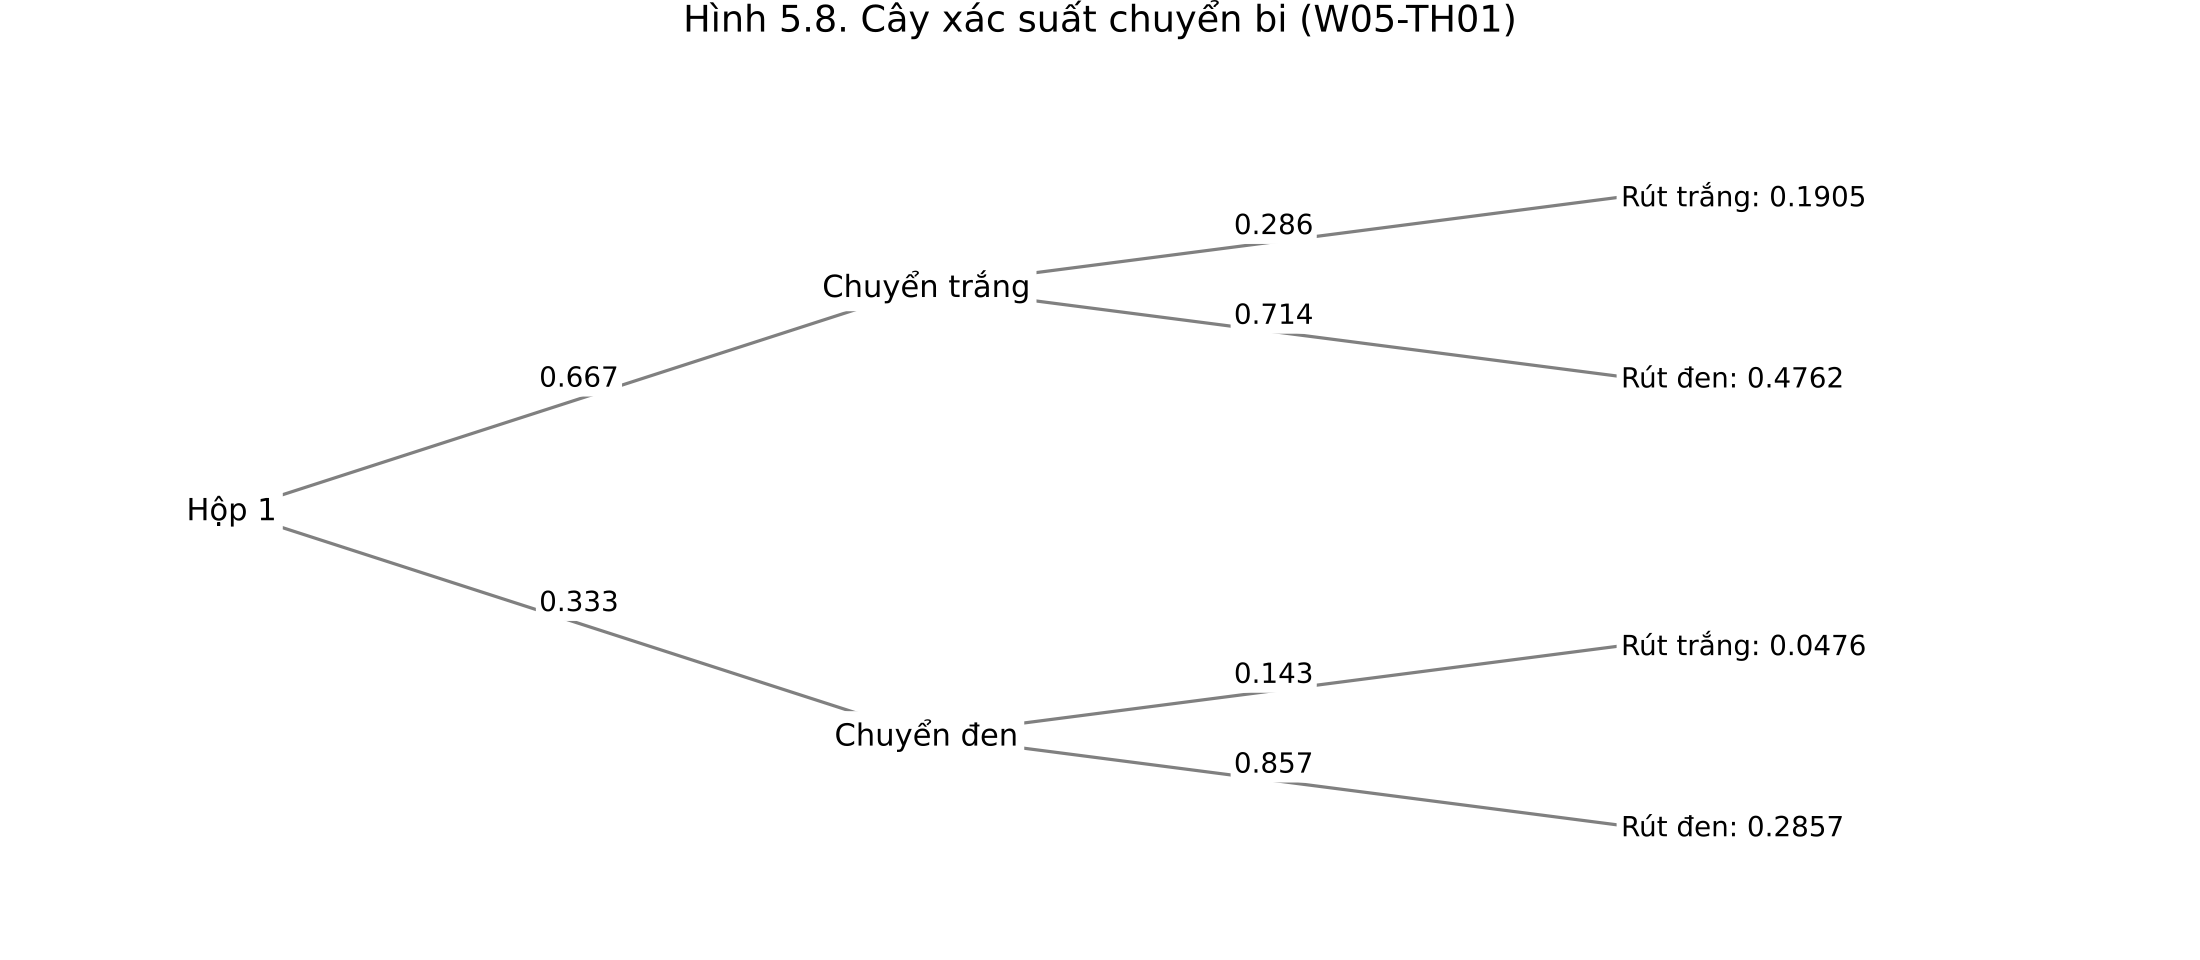

In [18]:
segments, branch_labels, transfer_nodes, outcome_nodes = [], [], [], []
for label, p_first, y, p_white in [("Chuyển trắng", 2/3, 0.75, 2/7),
                                   ("Chuyển đen", 1/3, 0.25, 1/7)]:
    segments.append({"x": 0.0, "y": 0.5, "xend": 3.0, "yend": y})
    branch_labels.append({"x": 1.5, "y": (0.5+y)/2+0.025, "label": f"{p_first:.3f}"})
    transfer_nodes.append({"x": 3.0, "y": y, "label": label})
    for second, p_second, delta in [("Rút trắng", p_white, 0.1), ("Rút đen", 1-p_white, -0.1)]:
        segments.append({"x": 3.0, "y": y, "xend": 6.0, "yend": y+delta})
        branch_labels.append({"x": 4.5, "y": y+delta/2+0.02, "label": f"{p_second:.3f}"})
        outcome_nodes.append({"x": 6.0, "y": y+delta, "label": f"{second}: {p_first*p_second:.4f}"})
root_node = pd.DataFrame({"x": [0.0], "y": [0.5], "label": ["Hộp 1"]})
transfer_tree = (
    p9.ggplot()
    + p9.geom_segment(pd.DataFrame(segments), p9.aes("x", "y", xend="xend", yend="yend"),
                      color="gray", size=0.65)
    + p9.geom_label(pd.DataFrame(branch_labels), p9.aes("x", "y", label="label"),
                    size=10, label_size=0, label_padding=0.12)
    + p9.geom_label(pd.DataFrame(transfer_nodes), p9.aes("x", "y", label="label"),
                    size=11, label_size=0, label_padding=0.2)
    + p9.geom_label(root_node, p9.aes("x", "y", label="label"), size=11,
                    label_size=0, label_padding=0.2)
    + p9.geom_label(pd.DataFrame(outcome_nodes), p9.aes("x", "y", label="label"),
                    ha="left", size=10, label_size=0, label_padding=0.16)
    + p9.coord_cartesian(xlim=(-1, 8.5), ylim=(0, 1), expand=False)
    + p9.labs(title="Hình 5.8. Cây xác suất chuyển bi (W05-TH01)")
    + p9.theme_void()
    + p9.theme(figure_size=(11, 4.8))
)
display(transfer_tree)


### W05-TH03: Truy loại lô từ hai linh kiện kiểm tra

Lô có 10 linh kiện. Trong toàn bộ lô, 50% có 0 lỗi, 30% có 1 lỗi, 20% có 2 lỗi. Chọn đều một lô, lấy đều hai linh kiện khác nhau không hoàn lại, kiểm tra chính xác. Tính xác suất lô có 0/1/2 lỗi khi (1) cả hai được kiểm tra đều tốt; (2) đúng một linh kiện được kiểm tra bị lỗi.

<details><summary>Đáp án và lập luận — W05-TH03</summary>

Gọi $A_i$: lô có $i$ lỗi ($i=0,1,2$); $B$: hai linh kiện được kiểm tra đều tốt; $C$: đúng một linh kiện lỗi.

*Bước 1: xác suất ban đầu.* $P(A_0)=\frac12$, $P(A_1)=\frac3{10}$, $P(A_2)=\frac15$.

*Bước 2: xác suất của bằng chứng trong từng loại lô.* Rút lần lượt hai linh kiện không hoàn lại và dùng quy tắc nhân. Lần rút thứ hai dùng thành phần lô đã thay đổi.

- Lô 0 lỗi: $P(B\mid A_0)=1$, $P(C\mid A_0)=0$.
- Lô 1 lỗi (9 tốt): $P(B\mid A_1)=\frac9{10}\cdot\frac89=\frac45$. Đúng một lỗi có hai thứ tự, lỗi–tốt và tốt–lỗi; chúng xung khắc nên cộng được: $P(C\mid A_1)=\frac1{10}\cdot\frac99+\frac9{10}\cdot\frac19=\frac15$.
- Lô 2 lỗi (8 tốt): $P(B\mid A_2)=\frac8{10}\cdot\frac79=\frac{28}{45}$; $P(C\mid A_2)=\frac2{10}\cdot\frac89+\frac8{10}\cdot\frac29=\frac{16}{45}$.

| Loại lô | $P(A_i)$ | $P(B\mid A_i)$ | $P(C\mid A_i)$ |
|---|---|---|---|
| 0 lỗi | $1/2$ | $1$ | $0$ |
| 1 lỗi | $3/10$ | $4/5$ | $1/5$ |
| 2 lỗi | $1/5$ | $28/45$ | $16/45$ |

*Bước 3: câu 1, xác suất toàn phần rồi Bayes.*
$$P(B)=\frac12\cdot1+\frac3{10}\cdot\frac45+\frac15\cdot\frac{28}{45}=\frac{225+108+56}{450}=\frac{389}{450}.$$
$$\big(P(A_0\mid B),\,P(A_1\mid B),\,P(A_2\mid B)\big)=\left(\frac{225}{389},\frac{108}{389},\frac{56}{389}\right)\approx(0{,}5784;\ 0{,}2776;\ 0{,}1440).$$

*Bước 4: câu 2.*
$$P(C)=\frac12\cdot0+\frac3{10}\cdot\frac15+\frac15\cdot\frac{16}{45}=\frac{27+32}{450}=\frac{59}{450}.$$
$$\big(P(A_0\mid C),\,P(A_1\mid C),\,P(A_2\mid C)\big)=\left(0,\frac{27}{59},\frac{32}{59}\right)\approx(0;\ 0{,}4576;\ 0{,}5424).$$

*Nhận xét.* Hai linh kiện tốt chưa bảo đảm cả lô tốt: xác suất lô 0 lỗi chỉ tăng từ 0,5 lên khoảng 0,58. Đúng một lỗi loại hẳn lô 0 lỗi, và làm lô 2 lỗi có xác suất sau cập nhật lớn nhất.

</details>

**Code.** Ô dưới kiểm tra bảng của W05-TH03 bằng cách liệt kê.

- `sample_pairs` liệt kê 90 cặp chỉ số khác nhau $(i,j)$ từ 0 đến 9: mọi cách rút hai linh kiện có thứ tự, không hoàn lại. Các cặp đồng khả năng.
- Với lô có `k` lỗi, ta coi `k` linh kiện đầu (chỉ số nhỏ hơn `k`) là lỗi. Gắn nhãn lỗi cho linh kiện nào cũng cho cùng xác suất, vì mọi cặp đồng khả năng.
- `(sample_pairs < k).sum(axis=1)` đếm số linh kiện lỗi trong mỗi cặp.
- `lot_joint` là quy tắc nhân; `evidence_probs` là xác suất toàn phần; `lot_posterior` là Bayes. Các lệnh `assert` cuối ô so với phân số tính tay.

Tuần 06 sẽ viết phép đếm này thành một phân phối (phân phối siêu bội).

In [19]:
lot_prior = np.array([0.5, 0.3, 0.2])
sample_pairs = np.array([(i, j) for i in range(10) for j in range(10) if i != j])
likelihoods = []
for k in [0, 1, 2]:
    observed_defects = (sample_pairs < k).sum(axis=1)
    likelihoods.append([(observed_defects == 0).mean(), (observed_defects == 1).mean()])
likelihoods = np.array(likelihoods)
lot_joint = lot_prior[:, None] * likelihoods
evidence_probs = lot_joint.sum(axis=0)
lot_posterior = lot_joint / evidence_probs
display(pd.DataFrame({"Loại lô (số lỗi)": [0, 1, 2], "Ban đầu": lot_prior,
                      "P(hai tốt | loại)": likelihoods[:, 0],
                      "P(một lỗi | loại)": likelihoods[:, 1],
                      "Sau hai tốt": lot_posterior[:, 0], "Sau một lỗi": lot_posterior[:, 1]}))
print("P(hai tốt), P(một lỗi):", evidence_probs)
assert np.allclose(lot_posterior.sum(axis=0), 1)
assert np.allclose(lot_posterior[:, 0], np.array([225, 108, 56])/389)
assert np.allclose(lot_posterior[:, 1], np.array([0, 27, 32])/59)

,Loại lô (số lỗi),Ban đầu,P(hai tốt | loại),P(một lỗi | loại),Sau hai tốt,Sau một lỗi
0,0,0.5,1.000000,0.000000,0.578406,0.000000
1,1,0.3,0.800000,0.200000,0.277635,0.457627
2,2,0.2,0.622222,0.355556,0.143959,0.542373


P(hai tốt), P(một lỗi): [0.86444444 0.13111111]


## 8. Tóm tắt và lỗi hay gặp

| Công thức | Đọc thành lời |
|---|---|
| $P(\overline{A})=1-P(A)$ | Xác suất không xảy ra bằng 1 trừ xác suất xảy ra. |
| $P(A)=\lvert A\rvert/\lvert\Omega\rvert$ | Khi mọi kết quả đồng khả năng: số kết quả thuận lợi chia cho tổng số kết quả. |
| $P(A\cup B)=P(A)+P(B)-P(A\cap B)$ | Cộng hai xác suất thì phần chung bị tính hai lần, nên trừ đi một lần. |
| $P(A\mid B)=\dfrac{P(A\cap B)}{P(B)}$ | Trong những lần $B$ xảy ra, tỉ lệ lần $A$ cũng xảy ra. |
| $P(A\cap B)=P(A)\,P(B\mid A)$ | Xác suất cả hai bằng xác suất bước đầu nhân xác suất bước sau khi bước đầu đã xảy ra. |
| $P(A\cap B)=P(A)\,P(B)$ | Định nghĩa độc lập: biết một biến cố không làm đổi xác suất của biến cố kia. |
| $P(B)=\sum_i P(B\mid A_i)\,P(A_i)$ | Chia theo nhóm, tính trong từng nhóm, rồi cộng có trọng số. |
| $P(A_j\mid B)=\dfrac{P(B\mid A_j)\,P(A_j)}{\sum_i P(B\mid A_i)\,P(A_i)}$ | Phần đóng góp của nhóm $A_j$ vào $B$, chia cho tổng đóng góp. |
| $1-(1-p)^n$ | Xác suất ít nhất một lần xảy ra trong $n$ lần độc lập, mỗi lần với xác suất $p$. |

Ta đã giải được bài De Méré bằng phần bù và tính độc lập. W05-TH03 cho thấy thông tin mới làm thay đổi xác suất của các nhóm ban đầu. Mọi kết luận đó chỉ đúng dưới giả định của mô hình.

### Lỗi hay gặp

| Lỗi | Sửa |
|---|---|
| Coi $P(A\mid B)$ và $P(B\mid A)$ là một | Xác định mẫu số trước khi tính. |
| Coi xung khắc là độc lập | Xung khắc với xác suất dương thì **phụ thuộc**. |
| Nhân xác suất mà chưa kiểm tra độc lập | Viết $P(A)\,P(B\mid A)$; chỉ thay bằng $P(A)\,P(B)$ khi có lý do để tin là độc lập. |
| Cộng xác suất của các biến cố có thể cùng xảy ra | Dùng phần bù hoặc quy tắc cộng tổng quát. |
| Dùng $\lvert A\rvert/\lvert\Omega\rvert$ khi các kết quả không đồng khả năng | Liệt kê lại ở cấp đồng khả năng: từng vé, từng cặp có thứ tự. |
| Lấy trung bình cộng đơn giản các tỉ lệ nhóm | Dùng trung bình có trọng số, tức xác suất toàn phần. |
| Viết $P(A\mid\overline{B})=1-P(A\mid B)$ | Sai. Quy tắc phần bù chỉ áp dụng cho biến cố đứng trước dấu $\mid$. |

## 9. Tự kiểm tra trước Tuần 06

Trước mỗi phép tính, hãy tự hỏi:

1. Phép thử là gì? Không gian mẫu gồm những kết quả nào? Biến cố cần tính là tập nào?
2. Cơ chế chọn là gì: có hoàn lại hay không? Các kết quả có đồng khả năng không?
3. Khi cộng: các biến cố có xung khắc không? Phần giao có bị đếm lặp không?
4. Khi nhân: đã viết xác suất có điều kiện chưa? Chỉ thay bằng xác suất không điều kiện khi có độc lập.
5. Khi đổi chiều điều kiện: mẫu số mới là nhóm nào? Có cần dùng Bayes không?

**Câu hỏi.**

1. Cho $P(A)=0{,}5$, $P(B)=0{,}4$, $P(A\cup B)=0{,}7$. Tính $P(A\cap B)$, $P(A\setminus B)$ và $P(\overline{A}\cap\overline{B})$.
2. Có thể có $P(A)=0{,}6$, $P(B)=0{,}7$ và $A\cap B=\varnothing$ không?
3. Cho $P(A)=0{,}3$, $P(B)=0{,}5$, $P(A\cap B)=0{,}15$. $A$ và $B$ có độc lập không? Có xung khắc không?
4. Tung một đồng xu cân đối 10 lần đều ra ngửa. Vì sao câu "lần 11 nhiều khả năng ra sấp hơn" là sai?

<details><summary>Đáp án tự kiểm tra</summary>

1. $P(A\cap B)=0{,}5+0{,}4-0{,}7=0{,}2$. $P(A\setminus B)=0{,}5-0{,}2=0{,}3$. $P(\overline{A}\cap\overline{B})=P(\overline{A\cup B})=1-0{,}7=0{,}3$ (De Morgan rồi phần bù).
2. Không. Nếu rời nhau thì $P(A\cup B)=0{,}6+0{,}7=1{,}3>1$, vô lý.
3. Độc lập, vì $0{,}3\cdot0{,}5=0{,}15$. Không xung khắc, vì $P(A\cap B)=0{,}15>0$.
4. Các lần tung độc lập, nên $P(\text{sấp ở lần 11}\mid\text{10 lần đầu ngửa})=P(\text{sấp})=\frac12$. Đồng xu không "nhớ" các lần trước.

</details>

Tuần 06 chuyển từ biến cố sang **đại lượng số**. Nếu $X$ là tổng hai xúc xắc, hay số linh kiện lỗi trong mẫu, thì $X$ nhận những giá trị nào, và mỗi giá trị có xác suất bao nhiêu? Trước buổi sau, hãy ôn lại không gian mẫu, quy tắc cộng, quy tắc nhân và lấy mẫu có hoặc không hoàn lại.

## 10. Đọc thêm trong STAT 20 bản dịch

- **§3.1 Nền tảng xác suất:** nghịch lý De Méré, không gian mẫu, tiên đề, sơ đồ Venn, hộp vé, đồng xu thiên vị, roulette.
- **§3.3 Tính toán xác suất:** Sally Clark, xác suất có điều kiện, quy tắc nhân, độc lập, bao hàm–loại trừ.

Mục §3.2 hướng dẫn ngôn ngữ R; học phần dùng Python nên có thể bỏ qua.

<details><summary><b>Thông tin cho giảng viên</b> Nguồn và đối chiếu trang slide</summary>

Đề cương UET.MAT1052, Buổi 5, mục 3.1–3.3 (LLO5.1–5.2) quyết định phạm vi. `Slides/week05.pdf` của Hoàng Thị Điệp, Nghiêm Nguyễn Việt Dũng, Lê Thị Hường quyết định kiến thức, ví dụ và **18 mã bài tập**. Không tự bổ sung các mã BT03, BT06 hoặc TH02 vốn không có trong slide.

| Trang slide | Nội dung trong notebook |
|---|---|
| 1–8 | Đầu bài và mở đầu: mục tiêu, xác suất và khái quát dữ liệu |
| 9–12 | Mục 1: De Méré; W05-Q01 |
| 13–29 | Mục 2: không gian mẫu, phép toán tập hợp, Venn, De Morgan; BT01–02, Q02, EX01 |
| 30–37 | Mục 3: tiên đề, hệ quả, đồng khả năng, quy tắc cộng; bảng 137 hộ |
| 38–55 | Mục 4: có điều kiện, quy tắc nhân, độc lập, Sally Clark; EX02–03, BT04–05 |
| 70–72 | Mục 4: xung khắc khác độc lập; Q03 |
| 73–80 | Mục 5: lời giải và mô phỏng De Méré; CH01 |
| 56–69 | Mục 6: toàn phần, Bayes, cây SIR; EX04–05, BT07–08 |
| 81–90 | Mục 7: CASE01, TH01, TH03; lời giải và kiểm tra số |
| 91–93 | Mục 9: tự kiểm tra và chuyển tiếp Tuần 06 |

`STAT20_in_Vietnamese.html`, §3.1–3.3: bổ sung đồng xu, hộp vé, roulette, bao hàm–loại trừ và 20 hình minh họa (5.S1–5.S20), nay đặt ngay tại khái niệm tương ứng. Số liệu giả định hoặc mô phỏng được phân biệt với dữ liệu quan sát.

Bản viết lại tháng 10/2026: xung khắc–độc lập chuyển vào mục 4; lời giải De Méré thành mục 5, trước Bayes; chứng minh đặt trong các khối "Vì sao?" (nguồn: phụ lục 04–05); ký hiệu phần bù thống nhất là $\overline{A}$. Seed của ô thiết lập giữ như cũ: bản Matplotlib/Plotly dùng 42, bản Plotnine dùng 4200; phần chữ không phụ thuộc seed.

Code chuyển sang Python, biểu đồ dùng Plotnine; cách đọc theo dữ liệu, ánh xạ thuộc tính hình ảnh và dạng hình học của Ngữ pháp đồ họa được giữ.

</details>